# Feature analysis — volume_normalised

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

To analyse a new feature, copy this notebook and change the parts specific to the feature:
**what it is and why** (§1), **its exact definition** (§2), and **its builder** — the
`volume_normalised` function in §3. The data loading, the checks, and the plots adapt on
their own.

**The example** is `volume_normalised`: a **single** EMA of a venue's traded volume,
**regime-normalised**. In one line —

`volume_normalised(ex; span)  =  ema_span(volume_ex)  /  yardstick`

where `ema_span(volume_ex)` is a single span-`N` EMA of venue `ex`'s per-trade-event traded size
(the **exp-weighted mean traded qty per trade-event**, an `E/W` `KernelMeanEMA`), and the
`yardstick` is **one of three** choices we build and compare: **none** (the un-normalised
baseline), **`σ_ev`** (the volatility yardstick), or **`λ_ev`** (the rate yardstick). A high value
means trades have been **large** lately, relative to the chosen regime gauge. It is a textbook
**rate-head (intensity)** feature — a volume/activity descriptor — and we check the price head too.

> **Relationship to `volume_surge`.** Both share the **same raw atom** — an EMA of traded volume —
> but explore **orthogonal axes**. `volume_surge` is `ema_fast(vol) / ema_slow(vol)`: a
> *self-normalising* ratio of two spans (the **fast/slow** axis), dimensionless by construction.
> `volume_normalised` is `ema_span(vol) / yardstick`: a *single* span divided by an *external* regime
> gauge (the **normalisation** axis). The fast/slow ratio cancels the volume *units* internally;
> dividing by a yardstick instead keeps one span's level but rescales it into vol- or rate-units.

**A feature's *analysis* is done when two checks pass:**
- **The parity check (§4)** — a second implementation reproduces the feature on real data, so the code really computes what we think it does.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale* — and the §10 checklist (streaming builder, tests, multi-block OOS) gates **shipping**: analysis-done is not ship-done.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime and you want it gone, dividing
by the yardstick is **one option** for removing it (only *when applicable* — you can't always
divide the regime out of a feature). Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`)
but **updated between trades** — they react to every byb mid-move, so they read live at every
instant. They use one fixed span, `YARDSTICK_N` (any feature may use that span too). (`σ_ev` is
the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many non-move
trades cancel out; `λ_ev` is a ratio of two EMAs — the exp-weighted byb move-count `W` (the same
`W` that is `σ_ev`'s denominator) ÷ the exp-weighted seconds-per-trade = byb's moves per second.) Like every average here, they live
on the trade-tick clock — never wall-clock or a hard window.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*,
one per possible move-count: "if `k` moves happen, here's the spread of the total price
change" (call it `D_k`). The rate head gives the probability of each count, `P(K = k)`. The
100 ms move is the two **mixed** — for every count `k`, take the price head's `k`-move
distribution, weight it by the rate head's probability of exactly `k` moves, and sum:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's
`D_k` sets the shape. This is why a feature that predicts the *count* (rate head) and one that
predicts the *per-move direction* (price head) are both useful: they feed the two factors that
multiply together.

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns
over a fixed clock-time window look messy, but become well-behaved once you condition on the
*number* of events. So modelling the event count and the per-event move separately, then mixing
them, is a principled decomposition — not just a convenient one.

Every feature here feeds one or both heads, and borrows the matching yardstick when it needs
to be made comparable across markets. Two questions recur below: does a feature's *signed*
value predict the move (price head), and does its *magnitude*/level predict how many moves come
(rate head)? Those are diagnostics — the model is fed the **signed** feature for *both* heads,
and the rate head learns the level (and how features cancel or reinforce) on its own. And they
are **marginal screens** — does the feature carry signal worth feeding — **not** measures of
distributional fit: the model's actual targets are the count distribution `P(K = k)` and the
count-conditioned price family `D_k` mixed above, fit downstream, not what these rank-ICs measure
(§7 inspects the realised count/return distributions by feature bucket).

**Here the yardsticks play a double role.** They build the §5 controls and the rate-head target (as
always), *and* they are the **normalisers** the feature is divided by — so the normalisation axis is
"which model yardstick, if any, makes the raw volume EMA most useful." Trade **volume** is the
canonical subordinator/clock for price moves, so a volume EMA is squarely a **how-many** (intensity)
feature — `volume_normalised` is **primarily a rate-head feature**, but we check both heads.

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build
  the feature the same way for **every** venue (byb, okx, bin) and keep them all — byb is the
  target's own volume; the okx/bin legs test whether another venue's trade size leads byb's move-rate.
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads (often the most informative ones). Keep all; let the model weight them.
- **Don't pool exchanges by default.** Pooling can blur the cross-exchange structure. `volume_normalised`
  *is* poolable (one normalised volume EMA per venue), so first check per-exchange vs single vs pooled
  across time-scales (§9) — and we compute a real pooled leg there, not an illustrative note.
- **Don't normalize reflexively — but DO test it here, because that is the whole point of this
  feature.** A raw volume EMA is **not** dimensionless (unlike `volume_surge`'s ratio): its level
  carries the venue's intrinsic trade size *and* the volatility/rate regime. So the normalisation axis
  is a genuine question — we build the **un-normalised baseline**, `/ σ_ev`, and `/ λ_ev`, and **report
  which (if any) actually helps**, rather than assuming.
- **Don't invent your own vol/rate scale.** When we do normalize, use the model's yardstick
  (`σ_ev` or `λ_ev`), so the feature shares units with the target.
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — *especially acute
  here*: a volume EMA co-moves with the activity regime, so judge every leg by its **marginal/standalone**
  over the controls, never a raw univariate IC.
- **Don't ship a feature without the §4 parity check** — a second, production-style build reproducing it on real data.
- **Don't hand-roll a streaming EMA, and don't use `EventEMA` — use only `KernelMeanEMA` or `LiveFrontEMA`.**
  Every *online* average — the §4 production/streaming parity build, and any event-by-event EMA state anywhere
  in the notebook — MUST be exactly one of **two** `boba.ema` classes: **`KernelMeanEMA`** (the self-normalising
  `E / W` read — for a **flow**) or **`LiveFrontEMA`** (the live-front read — for a **level**). Both expose
  **separate `tick()` (decay) and `add()` (inject)** calls — that separation is the whole point: decay rides the
  shared trade clock (once per trade-timestamp) while injection rides each relevant-event timestamp, and the two
  must fire **independently** (see the inject-≠-decay rule below). **Never use `EventEMA`:** its single `step()`
  **couples decay and injection** into one call, so it *cannot* decay on the trade clock while injecting on a
  different event stream — that directly violates the inject-once / decay-once-independently rule. And **never**
  hand-roll a scalar EMA (no private `_ScalarEMA`, no `(1−α)·s + α·x` per-event loop) or reach for
  `scipy.signal.lfilter` in the streaming build. Every quantity here is either a **flow** (→ `KernelMeanEMA`) or
  a **level** (→ `LiveFrontEMA`); if you think you need anything else, you've mis-modelled it (a slope/covariance
  is a ratio of flow EMAs — several `KernelMeanEMA`s, not a bespoke class). §4 exists to validate the **actual
  production code** (`boba.ema` online vs §3's vectorized path), not a throwaway re-implementation that could
  carry the same blind spot. (The §3 *vectorized* analysis may still use `lfilter` — the offline array path, not
  online EMA state.)
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't over-transform for the network.** Pick the lightest reshaping that works.

**Do**
- **Do start with a falsifiable hypothesis** — a recent surge in *traded size* precedes more byb
  mid-moves. Disproof: no link to the forward move-count at any span/normalisation for any venue;
  or the link fully explained by the rate/vol controls.
- **Do make every average a trade-tick EMA.** *Every* smoother in the pipeline — the
  volume EMA, `σ_ev`, `λ_ev`, any rolling statistic — is an exponential moving average
  **decayed once per tick of the one shared trade clock** (one tick per trade-timestamp across **all** venues; simultaneous prints count once; `α = 2/(span+1)`) yet **taking in a fresh value at most once per timestamp that carries a relevant event** (a trade of its own venue, a byb move — same-timestamp events as one update, never stale between trades), **never** a wall-clock
  average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (one scalar
  per average, no ring buffers) and bit-identical online vs offline. Establish and validate the
  convention against a plain one-event-at-a-time loop on a real block — exactly as
  `notebooks/03_ema_clock_validation.ipynb` does, and as the §4 parity check re-checks here.
- **Do make every EMA react to relevant events as they land — never let it read a stale state.** An EMA's
  *decay* lives on the trade clock, but it must *update its value* at **each timestamp that carries a
  relevant event** (same-timestamp events aggregated to one update). For this volume flow, that relevant
  event is a trade of *its own* venue: it injects that timestamp's **summed** qty. A value that ignores its
  own trades since the last clock read is **stale** — wrong, and a silent source of lag. The choice of EMA
  *and when it updates* is what makes the read well-behaved — pick both deliberately (see the "Choosing the
  EMA" section).
- **Do inject at most one EMA sample per timestamp, and decay once per shared-trade-clock tick — this
  never changes.** At each timestamp an EMA injects **one** sample *iff* a relevant event for that EMA
  lands there: for the volume EMA, a trade of *this* venue (its summed qty); for `σ_ev`, a byb mid-move.
  A timestamp with only **irrelevant** trades injects nothing for that EMA, yet it still
  **ticks** (decays) once *iff* a trade lands, on the one **shared** trade clock
  (one tick per trade-timestamp across **all** venues, simultaneous prints counting once). Inject and
  decay are independent and neither ever fires more than once per timestamp, whatever the feature.
  Records sharing a timestamp are **one** sample, not a sequence: same-timestamp aggregation sets only
  that sample's **value** — never the number of samples, never the number of ticks. *What* value depends on the quantity: a **level**
  read takes the *last* state (mid, microprice); a **flow** **sums** the records at that timestamp
  (the volume EMA **sums** that timestamp's prints' `qty`). So a backed-up burst of N trade prints at one
  instant (one order sweeping levels) is still **one** weight-1 sample — value = the summed qty — **never** N
  samples. Injecting N silently overweights exactly the instants where a feed stalled and dumped a burst
  (N× weight on the `E/W` mean at one timestamp) and corrupts the count `W` that normalises it. (78% of byb
  prints in this block share a timestamp, so this matters a lot.) Time-order matters only on the clock — a
  timestamp with trades advances it **once**, not once per print.
- **Do treat all records sharing a timestamp as ONE event.** A burst of a venue's prints at the exact same
  instant is **one event carrying many fills** — **sum** their `qty` into a single injection; the shared
  clock advances **once** for that timestamp. (Unlike a level/gap feature, the volume `E/W` is
  piecewise-constant between this venue's trades — there is no live-front to refresh.)
- **Do read a sparse flow as `E / W`.** A venue's `qty` is carried only on *its* trade events. The
  volume EMA is a **`KernelMeanEMA`**: `add(Σqty)` on a venue trade (weight 1), `tick()` on every
  shared trade-timestamp; read `E / W` = mean qty **per venue trade**, with the non-venue ticks
  cancelling instead of counting as zeros and the warm-up bias divided out. (Pushing a `0` on a
  non-venue trade would silently turn "mean qty per venue trade" into "mean qty per *any* trade".)
  So an `E / W` on the **combined** trade clock at span `N` approximates that venue's **own**-clock
  EMA at a rescaled span — roughly `N` times that venue's share of the combined trade rate — i.e. you get
  genuine per-venue stats from the one shared clock. (That merged-clock ↔ own-clock equivalence — tight at
  large `N`, fraying at small `N` where the cross-venue lead/lag lives — is what
  `notebooks/03_ema_clock_validation.ipynb` validates.)
- **Do test against both heads — but feed both the *signed* feature.** The level→intensity (rate-head)
  check is the one that matters; the price-head check (signed `log(feature)` → direction) is a diagnostic
  we expect weak — traded volume is intensity, not direction. In the model, feed the **signed** feature to
  *both* heads, never a pre-computed `|feature|`; the rate head learns the level (and how venues' volumes
  cancel or reinforce) on its own.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future) — a single split is only a faster screen.
- **Do use the freshest valid price per exchange.**
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads.
- **Do prove regime-invariance with Gate A — never assume it.** A usable feature reads the *same* in calm and
  wild markets: its distribution must be **stable against the regime diagnostics we track** (not a proof of independence). Gate A's **control-free** checks (§6):
  **scale** (std stable across vol buckets, max/min < ~3); and — for **both the signed feature and its
  magnitude `|feature|`** (the rate head sees the signed feature but can learn its magnitude) — that it does **not track** the regime
  (`|IC(·, vol & rate level)| ≈ 0`, the monotone test) **nor leak non-monotonically** (per-decile-mean
  **dispersion** small, which catches a U-shaped leak the monotone IC misses). All are **hard** gates. A raw
  **level** (`σ_ev`, `λ_ev`, a mean trade size) usually *is* the regime and fails them — but *measure, don't
  assume*: a **ratio / bounded / normalised** form may pass, and even a ratio of two non-invariant levels can
  be invariant when they co-move. Never call a feature regime-invariant *or* not — nor a level useless — until
  **every** Gate A number says so. (Corollary: don't assert *any* property — invariance, a lead/lag, "it's
  circular" — you haven't measured on a real block.)
- **Don't fuse the two gates — they're independent.** *Regime invariance* (Gate A) is the feature's own
  distribution being stable across regimes; *signal* (Gate B) is what it predicts over the **invariant**
  controls. The raw vol/rate **levels aren't Gate-B controls** (they aren't valid alpha features) — putting them in
  the signal test just smuggles the Gate-A regime test back in; they serve only as the Gate-A regime *coordinate*. And **a control can be a valid feature**: when the
  feature under test *is* a regime descriptor, marginal-over-its-own-controls is circular — judge it on its
  **standalone** signal, and never call it "redundant" from its algebra alone.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.
If there's no story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | a single EMA of a venue's traded volume (mean qty per trade), regime-normalised — one number per venue, per span, per normalisation |
| **feeds** | both heads — primarily *intensity* (rate head: how many moves byb makes); the price head is checked too; both are fed the *signed* feature |
| **predicts** | byb's mid-price 100 ms from now |

**The idea.** For a venue's recent trades, take the **exp-weighted mean traded size per trade**
(an `E/W` EMA of `qty`), then divide by a regime gauge: `volume_normalised = ema(volume) / yardstick`,
`yardstick ∈ {1, σ_ev, λ_ev}`. Heavier recent trading should precede more byb mid-moves — trade
volume is the canonical activity clock for price moves.

**Why it should work.** A move over a window is *how many* little moves times *how big* each one is,
and the *number* of moves rides on how busy the market is. Traded volume is a direct read on that
busyness, so a recent surge in traded size should precede a burst of byb mid-moves (the rate head).
We expect little *directional* (price-head) signal — volume is intensity, not which way.

**Why three normalisations.** Unlike `volume_surge`'s self-normalising fast/slow ratio, a *single*
volume EMA is **not** unit-free: its level mixes the venue's intrinsic trade size with the
volatility/rate regime. So the normalisation axis is a real question — we build the **un-normalised
baseline**, `/ σ_ev`, and `/ λ_ev`, and **measure which (if any) helps**, gating hard on
regime-invariance (§6) rather than assuming.

**What would disprove it.** No link to the forward move-count at any span/normalisation for any
venue, or a link fully explained by the rate/vol controls (meaning it was only re-reporting "the
market is busy").

> **No fixed leader.** It's tempting to call one exchange "the leader." Don't — leadership
> moves around, and any exchange can lead at any moment. So build the feature *the same way
> for every exchange and keep them all*; never hard-code one as the leader. This feature is a
> genuine *per-exchange* number (one normalised volume EMA per venue), so §9 sweeps when keeping
> the venues separate beats a single venue or a pool.

## Choosing the EMA

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates at most once per timestamp that carries the EMA's own
relevant event** (same-timestamp events as one update). For `volume_normalised` the volume EMA is a
**sparse flow** — `qty` is carried only on *that venue's* trade events, not on every tick of the shared
clock — so it is the textbook case for the self-normalising `E / W` read. Choose the EMA type and
injection rule for the statistic being measured.

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- A **sparse flow** — present on only *some* events (a per-venue trade flow; byb's mid-moves): use
  **`KernelMeanEMA`**, the self-normalising `E / W`. The **volume EMA**: `add(total_qty)` on a venue
  trade (weight 1) and `tick()` on every shared trade-timestamp. `E` is the exp-weighted sum of the
  venue's qty; `W` is the exp-weighted count of the venue's trades; the read `E / W` is the
  **exp-weighted mean qty per venue trade** — a single span, no fast/slow ratio. (`σ_ev` / `λ_ev`, the
  yardsticks/normalisers, are the same `E/W` pattern over byb's *mid-move* stream.)
- A **forward-filled level** — defined at every instant (a price, a cross-venue gap) — would use
  **`LiveFrontEMA`** instead; this feature is a flow, not a level, so it does **not** use it.
- `KernelMeanEMA` and `LiveFrontEMA` are the **only** two classes you may use, and they share the
  `tick` / `add` / `value` interface (decay and injection are *separate* calls), so you A/B the two reads by
  swapping the class. (`LiveFrontEMA` composes a plain `EventEMA` internally for its committed part, but
  **never use `EventEMA` directly**: its single `step()` couples decay and injection, so it cannot decay on the
  trade clock while injecting on a separate event stream — the very thing the next section requires.)

**Choice 2 — *when* you push a value in** (the injection clock — a *separate* decision from the decay
clock). Decay is always once per trade-timestamp; injection is only for timestamps carrying the
quantity the EMA is measuring. The allowed patterns are:

| pattern | what it weights / measures | use for |
|---|---|---|
| only on the feature's real event, skip irrelevant clock ticks | a **per-real-event mean** | a flow (the volume EMA: push summed qty only on a trade of *this* venue; `σ_ev`: push `r²` only on a byb move) |
| commit every trade-timestamp; read refreshes each book-update timestamp | by **trade-dwell** — a value spanning more trades counts more | a level (gap, price) — not used here |

Classify the timestamp for the EMA being updated. We **inject** a venue's summed qty only on a real
venue trade. Pushing a `0` on a non-venue trade would silently turn "mean qty per venue trade" into
"mean qty per *any* trade" (contaminated by the other venues' trade rate) — the trap the `E / W` form
avoids.

Between trades:

- **Records sharing a timestamp are ONE event.** A burst of a venue's prints stamped at the *exact same
  instant* is **one event carrying many fills** — we **sum** their `qty` into a single injection, and
  the shared clock advances **once**.
- Because the flow is injected only at this venue's trade timestamps and `E / W` is invariant to the
  common decay shared by `E` and `W`, the feature's value is **piecewise-constant** between this venue's
  trades — there is no live-front to refresh. That makes the §4 parity check a clean, dead-simple
  streaming check.

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed; no peeking at the future.

**Measured on the trade clock** — markets alternate busy and quiet, so we count progress in *trades*
(one tick per trade-timestamp on any exchange — simultaneous prints are one tick) rather than in clock-seconds; that keeps the feature's meaning
steady whether trading is fast or slow.

**Comparable across calm and wild markets — the axis this feature exists to test.** Unlike a fast/slow
ratio, a single volume EMA is **not** unit-free: its level mixes the venue's intrinsic trade size with the
volatility/rate regime. We therefore build **three** versions and compare them in §6, rather than assume:

| leg | definition | what dividing does |
|---|---|---|
| **baseline** | `ema_span(volume_ex)` | nothing — the raw `E/W` mean qty per venue trade |
| **`/ σ_ev`** | `ema_span(volume_ex) / σ_ev` | rescales by byb's per-move **volatility** |
| **`/ λ_ev`** | `ema_span(volume_ex) / λ_ev` | rescales by byb's **move rate** (moves/sec) |

Put together, **for each venue `ex`, each span `N`, each normalisation**:

**2a — The shape** (the whole idea, in one line):

`volume_normalised(ex; N) = (E/W)_N(qty_ex) / yardstick`,  yardstick ∈ {1, σ_ev, λ_ev}.

The exp-weighted mean traded size per venue trade, rescaled by the chosen regime gauge. Stop here and
you have the feature — the rest is making each piece correct.

**2b — The EMAs we use, and how they update** (applying the two choices from the section above):

- **The volume EMA** is a **`KernelMeanEMA`** read as `E / W` over venue `ex`'s trade stream: on each
  `ex` trade-timestamp, `add(Σ qty of that timestamp's prints)` (weight 1); on every shared
  trade-timestamp, `tick()` (decay). Read `E / W` = mean qty per `ex` trade, at the single span `N`.
  Dividing by `W` removes the foreign-venue decay (the non-`ex` ticks cancel) and the warm-up bias,
  because `E` and `W` carry the *same* decay-and-warm-up factor that cancels in the ratio. Push a `0` on a
  non-`ex` trade instead and this silently becomes mean qty per *any* trade, diluted by the global rate.
- **`σ_ev`, `λ_ev`** (yardsticks/normalisers, span `YARDSTICK_N`) — a **sparse flow** over byb's
  *mid-moves*, each a **`KernelMeanEMA`**: `σ_ev = √(E/W)` over `byb_return²` (push only on a real byb
  mid-move), `λ_ev = W / E_dt` (the move-count `W` divided by an EMA of seconds-per-trade) = byb's
  moves/sec. Used for the controls, the rate-head target, **and** as the two normalisers.

Both reads obey the two between-trade rules from the section above. §3 builds exactly this; §4
re-derives the volume EMA from raw events one at a time and confirms it **bit-exact** (the yardsticks are
validated in the template/siblings and re-used unchanged).

The cell below loads the data, builds the shared trade clock, and computes **both yardsticks** as `E/W`
flows on that clock, span `YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict; byb mid feeds σ_ev/λ_ev & the targets
EXCHANGES   = ["byb", "okx", "bin"]              # volume_normalised is each venue's OWN traded volume; keep all (no leader)
# freshest mid per exchange (used only for the byb yardsticks/target). byb/okx use merged_levels; bin MUST use front_levels.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
SPANS       = [2, 10, 50, 200, 1000, 5000]      # the SINGLE-EMA span family swept (the lookback axis). NB: span=1 (α=1) is
                                                 # DEGENERATE for an E/W flow — the EMA fully decays to 0 each tick (E reads
                                                 # 0 right after the decay), so the smallest useful span for a flow is 2.
NORMS       = ["baseline", "sigma", "lambda"]   # the THREE normalisation legs: un-normalised, / σ_ev, / λ_ev
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev) — also the two normalisers
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# byb mid stream (for the yardsticks + target only)
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
byb_rx0, byb_mid0 = load_mid("byb")

# load every venue's trade stream: rx_time + qty, prc/qty>0 filtered; simultaneous prints summed later
trade_rx = {}; trade_qty = {}
trade_ts = []
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))           # drop bad prc=qty=0 prints
    rx = td["rx_time"].cast(pl.Int64).to_numpy(); q = td["qty"].to_numpy()
    trade_rx[ex] = rx; trade_qty[ex] = q
    trade_ts.append(rx)
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # shared trade clock: one tick per trade-TIMESTAMP (any venue)
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# --- byb yardsticks (σ_ev, λ_ev): react to every byb mid-move, decay once per shared trade ---
# They decay once per TRADE (memory in trade count) but INJECT on every byb mid-move, so a value read between
# trades reflects the moves since the last trade. σ_ev = √(E/W) over the byb-MOVE stream (E = squared returns,
# W = move count) — its E/W cancels the in-between trade decay. λ_ev = W / E_dt is a RATE: E_dt is a per-trade
# EMA of seconds/trade (flat between trades), so λ_ev = byb mid-moves per second.
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP rows to ONE update (the final mid)
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move: ONE per timestamp where the mid changed
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2                                       # move times + squared returns
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running count of byb mid-moves (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades (per-trade)
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, val, span):           # EWMA of `val` over the byb-MOVE stream, decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, mv_rx, "left")                               # trades strictly before each move (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the move stream (the partial epoch)
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — defined AT the anchor, reacting to every byb mid-move
    e_sq = _flow_at(anchors, mv_r2, span)                          # E: exp-weighted squared byb moves
    e_mv = _flow_at(anchors, np.ones(mv_r2.size), span)           # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (per-trade, held flat between trades)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second
    return sig, lam
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades (also the two normalisers)")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
yardsticks: react to every byb mid-move; decay span 10000 trades (also the two normalisers)


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in §4 — a streaming version
that does constant work per ingested trade (no growing buffers). They have to agree bit-for-bit.

We lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; note that adjacent
100 ms outcome windows still overlap ~50%, so neighbouring samples are correlated, which is exactly why
§5's walk-forward gate uses an embargo), read byb's actual move over the next 100 ms (the price target)
and its move count (the rate target), and compute the volume EMA at each grid point for **every
exchange** and **every span**, then divide by each of the three normalisers.

**The volume `E/W` build, vectorised.** For each venue: sum `qty` over simultaneous prints into one
value per venue-trade-timestamp, then form a single-span `KernelMeanEMA` flow — `add(Σqty)` on the
venue's trade-tick, `tick()` (decay) once on every shared trade-timestamp — read `E / W` at each anchor's
last clock tick (causal; the ratio is piecewise-constant between this venue's trades). `ema(volume) =
E/W`. The three legs are that one `E/W` divided by `1`, `σ_ev`, and `λ_ev`.

In [2]:
# evaluation grid (causal) + forward targets
WARMUP = 5 * max(YARDSTICK_N, max(SPANS))   # = 50000: enough trades for the slowest EMA/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target: byb's 100 ms signed return ÷ σ_ev
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (σ-units)

# per-venue: total qty per trade-TIMESTAMP (simultaneous prints summed into ONE event)
qty_ts = {}   # ex -> (unique_rx, summed_qty)
for ex in EXCHANGES:
    u, inv = np.unique(trade_rx[ex], return_inverse=True)
    qty_ts[ex] = (u, np.bincount(inv, weights=trade_qty[ex]))
print("summed simultaneous prints:", {ex: f"{len(trade_rx[ex]):,}->{len(qty_ts[ex][0]):,} ts" for ex in EXCHANGES})

def _ew_flow_at(anchors, val_rx, val, span):   # committed E of a KernelMeanEMA flow: 'add(val) on its trade-tick, then tick (decay) once'
    a = 2.0 / (span + 1.0)
    kt = np.searchsorted(merged_ts, val_rx, "left")          # the shared-clock tick index of each venue-trade timestamp (events sit AT a tick)
    inj = np.zeros(n_ticks); np.add.at(inj, kt, a * val)     # the injection a*val at that tick (BEFORE that tick's decay)
    E = lfilter([1.0], [1.0, -(1.0 - a)], (1.0 - a) * inj)   # E after each tick: E_t = (1-a)*(E_{t-1}+inj_t) — one decay per injection at its own tick
    return E[np.searchsorted(merged_ts, anchors, "right") - 1]   # committed E after the last shared tick <= anchor (flat between ticks)

def volume_ema(ex, span):                          # ema(volume) = E/W = exp-weighted mean qty per venue trade, single span
    u, q = qty_ts[ex]; ones = np.ones_like(q)
    E = _ew_flow_at(anchor_ts, u, q, span);  W = _ew_flow_at(anchor_ts, u, ones, span)
    return E / np.maximum(W, 1e-300)

def volume_normalised(ex, span, norm):             # THE FEATURE: ema(volume) / yardstick (norm in {baseline, sigma, lambda})
    v = volume_ema(ex, span)
    if norm == "baseline": return v
    if norm == "sigma":    return v / np.maximum(sigma_at_anchor, 1e-300)
    if norm == "lambda":   return v / np.maximum(lam_at_anchor, 1e-300)
    raise ValueError(norm)
print(f"grid: {len(anchor_ts):,} anchors")
for ex in EXCHANGES:
    demo = volume_ema(ex, 50)
    print(f"  ema(volume_{ex}, span=50): median {np.nanmedian(demo):.4g}  p10 {np.nanpercentile(demo,10):.4g}  p90 {np.nanpercentile(demo,90):.4g}")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


summed simultaneous prints: {'byb': '1,618,754->351,008 ts', 'okx': '889,567->585,948 ts', 'bin': '3,689,867->745,299 ts'}
grid: 1,706,369 anchors


  ema(volume_byb, span=50): median 0.8638  p10 0.2368  p90 3.997


  ema(volume_okx, span=50): median 1.948  p10 0.644  p90 6.836


  ema(volume_bin, span=50): median 1.723  p10 0.6346  p90 5.377


## 4. Check the code is right — a parity check (a production-style streaming build)

**Non-negotiable.** Reproduce the **volume EMA** with a second, **streaming/online** build and confirm
the two agree on real data, **bit-exact**, **for every per-exchange leg**. This online build drives the
**ACTUAL production EMA class** — `boba.ema.KernelMeanEMA` — **not** a hand-rolled scalar twin and **not**
independent of `boba.ema`: per the guard rail, §4 exists to validate the *production code* (`boba.ema`
online vs §3's vectorized path), never a throwaway re-implementation that could carry the same blind spot.
It is an O(1) state machine you push **raw trade events** into — `on_trade(...)` then `refresh()` — and
read `ema(volume)` per exchange per span from `value()`. State lives **inside** the EMA: one
`KernelMeanEMA` per venue per span, holding two scalars `(E, W)` and advanced by its own
`add(Σqty)` / `tick()` — no buffers, no history, independent of how long it runs. The *online* form (one
feed in, decay on the shared clock, inject per venue trade) is what's checked here; matching §3's
vectorized path bit-for-bit is the cross-check that both are right.

We validate the **volume EMA** (the only new machinery) **bit-exact**; the three normalisers are the
template's already-validated `σ_ev` / `λ_ev` applied by a plain division, so dividing a bit-exact EMA
by them is correct by construction — but we also confirm one full `/σ_ev` leg end-to-end against the
§3 vectorised feature. (That leg's tolerance is looser than the raw EMA's: dividing a ~1e-14 EMA
round-off by a tiny `σ_ev` ≈ 1e-4 amplifies it by `1/σ_ev`, so the *normalised* leg matches to ~1e-9 —
float32 tolerance, the expected amplification, not a logic gap. The raw volume EMA is asserted
bit-exact at < 1e-9; the normalised leg at the amplified < 1e-6.)

**The design:**
- Fed **only raw trade events**, each tagged by its venue. Each venue keeps one `KernelMeanEMA` per span
  over its `qty` (the production self-normalising E/W flow mean — the EMA holds the `(E, W)` state).
- Events sharing a **timestamp are one event**: the driver collects every print at a timestamp,
  **sums** each venue's `qty`, then calls **`refresh()` once** — which `add`s each venue's summed qty
  to that venue's EMAs (only venues that traded), then advances the shared clock **once** (`tick()`
  every venue's EMAs) because a trade landed at this timestamp.
- `value()` returns `E/W` per venue per span, current at the instant it is read.

We feed the **whole raw trade stream** (every venue's trades) into **one** builder and read **all
three** venues' volume EMAs at each grid anchor. If the online build reproduces §3's vectorised volume
EMA on real data bit-for-bit, both are right.

In [3]:
# PRODUCTION-EMA PARITY BUILD — the streaming/online build drives the ACTUAL production EMA class,
# boba.ema.KernelMeanEMA, NOT a hand-rolled scalar twin. (Per the guard rail: every online average is exactly
# one of two boba.ema classes — KernelMeanEMA for a flow, LiveFrontEMA for a level — and §4 exists to validate
# that production code against §3's vectorized path, never a throwaway re-implementation that could carry the
# same blind spot. The volume EMA is a sparse FLOW -> KernelMeanEMA, read E/W.) One KernelMeanEMA per venue per
# span; add(Σqty) on a venue trade (weight 1), tick() ONCE per shared trade-timestamp (the decay clock), value()
# = E/W = exp-weighted mean qty per venue trade. State is O(1) (the EMA holds two scalars E, W internally) — no
# buffers, no history. If this online KernelMeanEMA build matches §3's vectorized path bit-for-bit, both are right.
from boba.ema import KernelMeanEMA

class LiveVolumeEMA:
    # Per venue per span: a self-normalising E/W flow mean over qty (E/W = mean qty per venue trade), held by ONE
    # boba.ema.KernelMeanEMA instance. on_trade only ACCUMULATES this timestamp's qty per venue; the driver calls
    # refresh() ONCE per timestamp, which add()s each venue's SUMMED qty (one event per timestamp, never per print)
    # then tick()s the shared clock once (decay every EMA). value() reads each EMA's committed E/W.
    def __init__(self, exchanges, spans):
        self.exchanges = list(exchanges); self.spans = list(spans)
        self.ema = {e: {N: KernelMeanEMA(N) for N in self.spans} for e in self.exchanges}   # the PRODUCTION flow EMA, one per venue·span
        self.pending = {}                                              # venue -> summed qty at the current timestamp

    def on_trade(self, ex, qty):                                       # accumulate this timestamp's qty for the venue (sum simultaneous prints)
        self.pending[ex] = self.pending.get(ex, 0.0) + qty

    def refresh(self):                                                 # ONE per TIMESTAMP: inject each venue's summed qty, then decay everyone once
        for ex, q in self.pending.items():                            # inject only venues that traded this timestamp (sparse flow; non-traders stay non-observations)
            for N in self.spans:
                self.ema[ex][N].add(q)                                # KernelMeanEMA.add: E += α·qty, W += α  (weight 1)
        self.pending = {}
        for ex in self.exchanges:                                     # a trade landed at this timestamp -> the shared clock advances once: tick (decay) every venue's EMA
            for N in self.spans:
                self.ema[ex][N].tick()                                # KernelMeanEMA.tick: E *= (1-α), W *= (1-α)

    def value(self, ex, span):                                        # ema(volume) per venue per span: KernelMeanEMA's committed E/W (mean qty per venue trade)
        return self.ema[ex][span].value()                            # E/W if W>0 else nan

# --- gather the WHOLE raw trade stream (every venue) over a slice ---
SPAN_CHK, N_GRID = 50, 40_000                      # validate ALL venues at one representative span over the first ~N_GRID grid points
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])
cols = {k: [] for k in "rx eid qty".split()}       # eid = integer venue code
for eid, ex in enumerate(EXCHANGES):
    rx, q = trade_rx[ex], trade_qty[ex]
    m = rx <= cutoff
    cols["rx"].append(rx[m]); cols["eid"].append(np.full(int(m.sum()), eid, np.int8)); cols["qty"].append(q[m])
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.argsort(C["rx"], kind="stable")          # rx ascending; venue order within a tie is irrelevant (we sum)
rxL, eidL, qtyL = (C[k][order].tolist() for k in "rx eid qty".split())
print(f"streaming {len(rxL):,} raw trade events (all venues) over ~{N_GRID:,} grid points...")

# --- the CALLER drives it: apply each timestamp's trades, refresh() once, READ value() at every grid anchor ---
feat = LiveVolumeEMA(EXCHANGES, [SPAN_CHK])
na = min(N_GRID, len(anchor_ts))
streams = {ex: np.full(na, np.nan) for ex in EXCHANGES}
n = len(rxL); i = 0; ai = 0
while i < n:
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:           # read every anchor whose state is settled (all events before rx applied)
        for ex in EXCHANGES: streams[ex][ai] = feat.value(ex, SPAN_CHK)
        ai += 1
    while i < n and rxL[i] == rx:                    # apply EVERY print stamped at this nanosecond (sum into pending)
        feat.on_trade(EXCHANGES[eidL[i]], qtyL[i]); i += 1
    feat.refresh()                                   # one event per timestamp: inject summed qty, decay once
while ai < na:
    for ex in EXCHANGES: streams[ex][ai] = feat.value(ex, SPAN_CHK)
    ai += 1

# --- one stream -> three live volume EMAs: check EACH venue against its §3 vectorized build, BIT-EXACT ---
print(f"one raw-trade stream -> {len(EXCHANGES)} live volume EMAs, vs the vectorized build (span={SPAN_CHK}):")
worst = 0.0
for ex in EXCHANGES:
    ref = volume_ema(ex, SPAN_CHK)[:na]
    both = np.isfinite(streams[ex]) & np.isfinite(ref)
    diff = np.abs(streams[ex][both] - ref[both]); md_ = float(np.nanmax(diff)); worst = max(worst, md_)
    print(f"  {ex}:  max |diff| {md_:.2e}  on {int(both.sum()):,} grid points")
    assert md_ < 1e-9, f"live build does not reproduce the {ex} volume EMA (max|diff|={md_:.2e})"

# --- also confirm a FULL normalised leg (/σ_ev) end-to-end: streaming EMA / template σ_ev == §3 feature ---
ex0 = "byb"
ref_norm = volume_normalised(ex0, SPAN_CHK, "sigma")[:na]
live_norm = streams[ex0] / np.maximum(sigma_at_anchor[:na], 1e-300)
both = np.isfinite(live_norm) & np.isfinite(ref_norm)
dn = float(np.nanmax(np.abs(live_norm[both] - ref_norm[both])))
print(f"  {ex0} /σ_ev full normalised leg:  max |diff| {dn:.2e}  on {int(both.sum()):,} grid points"
      f"  (~1/σ_ev amplification of the {worst:.0e} EMA round-off; σ_ev median {np.nanmedian(sigma_at_anchor):.1e})")
assert dn < 1e-6, "normalised leg mismatch"     # looser than the raw EMA's 1e-9: dividing by σ_ev≈1e-4 amplifies the EMA round-off by 1/σ_ev
print(f"parity: one raw-trade stream reproduces ALL {len(EXCHANGES)} venues (volume EMA bit-exact, worst |diff| {worst:.2e}) "
      f"+ a full /σ_ev normalised leg ({dn:.2e}, ~1/σ_ev amplified)  OK")

streaming 585,061 raw trade events (all venues) over ~40,000 grid points...


one raw-trade stream -> 3 live volume EMAs, vs the vectorized build (span=50):


  byb:  max |diff| 3.55e-14  on 40,000 grid points


  okx:  max |diff| 3.55e-14  on 40,000 grid points


  bin:  max |diff| 5.68e-14  on 40,000 grid points


  byb /σ_ev full normalised leg:  max |diff| 1.16e-09  on 40,000 grid points  (~1/σ_ev amplification of the 6e-14 EMA round-off; σ_ev median 2.8e-05)
parity: one raw-trade stream reproduces ALL 3 venues (volume EMA bit-exact, worst |diff| 5.68e-14) + a full /σ_ev normalised leg (1.16e-09, ~1/σ_ev amplified)  OK


**Conclusion.** From one stream of raw trade events the streaming reimpl reproduces **every** venue's
vectorised volume EMA to floating-point round-off — the recursive EMAs' last-digit drift only, i.e.
**bit-exact** (asserted `< 1e-9`; the printed worst |diff| is far below that). The production shape
(one feed in, an `E/W` per venue out) computes exactly what the offline analysis did, on the one shared
trade clock. Crucially, the reimpl independently **sums simultaneous prints into one event** and **decays
the shared clock once per timestamp** — matching it confirms the vectorised build handles the
78%-simultaneous byb prints correctly. The `/σ_ev` end-to-end check (`< 1e-6`) confirms the normalisation
is just a division of two already-validated quantities; its slightly looser tolerance is the *expected*
`1/σ_ev` amplification of the EMA's round-off (σ_ev ≈ 1e-4), not a logic gap — so all three normalisation
legs inherit the volume EMA's correctness.

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates are **two independent tests** (see the
Gate A / Gate B box in §6): **(A)** is the feature **regime-invariant** — a stable distribution that
doesn't leak the vol/rate state — and **(B)** does it **predict** something the market's current state
doesn't already tell us? The only **controls** for Gate B are the two **regime-invariant momenta**:
- **rate momentum** — from `λ_ev` (byb's mid-move rate): is byb moving more or less often than its own
  recent pace?
- **vol momentum** — the same, for volatility.
The raw **levels** of vol and rate (`log σ_ev`, `log λ_ev`) are **not** controls — they aren't
regime-invariant, so they're never model features; we keep them only as the regime *coordinate* for Gate A.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman —
robust to outliers), scored **out-of-sample with a purged, expanding-window walk-forward**:
each fold trains only on the *past*, leaves an **embargo gap** sized to clear the 100 ms
outcome windows with margin (so overlapping forward targets can't straddle the train→test
boundary). Note the embargo does **not** fully decorrelate the slow EMA/yardstick features:
their memory is ≈ `YARDSTICK_N` / (trades-per-sec) ≈ 140 s here — longer than the ~100 s
embargo — so re-check this if you slow the spans or use a thinner-traded block. The fold
scores on the *next* segment,
and we average over folds. That's the causal, production-style estimate — strictly past→future, as
it would run live. (A single 60/40 split is a faster screen, but it tests only one transition
and can swing ~2× on the luck of where the cut lands.)

Because adjacent samples are correlated (overlapping 100 ms labels + long EMA/yardstick memory), a single
point IC overstates its own precision — so for the **headline marginal** we also report the **per-fold** ICs
(did the gain hold in *every* OOS segment?) and a **block-bootstrap 90% CI** that resamples contiguous time
blocks sized to the EMA/yardstick memory (block length derived from the block's own trade-rate, not hard-coded),
so the interval respects the autocorrelation rather than pretending all anchors are independent.

Rank-IC is a **feature-screening** statistic, not a distributional score — proper scoring (NLL/CRPS, occurrence log-loss, calibration) and cost-aware utility are judged at the **model** level downstream, not in this per-feature template.

Beside the gates we run a **companion check**: the same marginal/standalone power computed **within calm /
mid / wild volatility buckets**. If the gain stays positive in all three, the signal is regime-stable, not
an artefact of one regime.

The gates that follow ask, separately: **Gate A** — is the feature's distribution stable across
volatility states (**scale**, plus neither the feature **nor its magnitude** `|feature|` tracks the regime level
(monotonically *or* non-monotonically), against **both** the vol and rate coordinate)? **Gate B** — does it *add* signal over the invariant
momentum controls, walk-forward? And the **companion** — does the Gate-B gain hold across calm / mid /
wild volatility, not just one regime?

> **Circularity caveat — `volume_normalised` is a `control` (a regime descriptor), so judge it on its
> STANDALONE signal.** It is an **activity/intensity** gauge, and the rate-head target is `count ÷ λ_ev` —
> itself an activity ratio. A feature that *is* a regime descriptor cannot be judged marginal-over-its-own
> regime controls (circular); we judge it **standalone**, on its own legs, with two saving graces specific
> to this feature: (i) **TRADE volume ≠ MOVE rate** — the `E/W` volume EMA is a **mean qty per trade** (trade
> *size*), even further from `λ_ev` than a trade-rate would be, so it may carry intensity information the
> move-rate control does not; (ii) the `/λ_ev` normalisation leg **divides by the very control**, which can
> manufacture a spurious `1/λ_ev` correlation with the count target's denominator — exactly why §6 gates the
> normalisation axis **hard on regime-invariance first** and compares the legs straight, never trusting a raw
> univariate IC. The okx/bin **cross-venue** legs stay a genuine lead test (another venue's trade size leading
> byb's move-rate — no own-feature circularity).

In [4]:
# --- the regime signals: the two INVARIANT momenta (the Gate B controls) + the two yardstick LEVELS
# (the regime COORDINATE for Gate A — used only to bucket/correlate against, NEVER as controls) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate — is byb moving more or less often than usual?
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower mid-move rate

# The gate machinery (walk-forward IC, Gate A/B, the block-bootstrap CI) lives in the shared, TESTED
# library boba.research.gates — defined once and used by every feature notebook (see tests/test_gates*.py;
# externally validated against the literature and adversarially reviewed). We import the primitives here and
# bind the regime scaffolding below into thin wrappers, so the call sites read the same while the logic
# stays in one validated place.
from boba.research import gates as _gates
from boba.research.gates import ic, wf_folds, wf_ic, wf_ic_by_regime, stratified_ic

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
# FEATURE_KIND drives GATE B below. "alpha" = a candidate signal that is NOT a regime descriptor
# (OFI, microprice, flow, price moves) -> judged on MARGINAL value over the controls. "control" = a
# regime descriptor (vol, rate, volume & their ratios/dynamics) -> itself a valid feature, but it
# OVERLAPS the controls, so it's judged on STANDALONE signal (its cross-venue legs stay a lead test).
FEATURE_KIND = "control"                                               # volume_normalised = a volume/activity regime descriptor (an intensity gauge), NOT a cross-venue alpha
base = [rate_momentum, vol_momentum]                                   # the ONLY controls: regime-INVARIANT momenta. Raw vol/rate LEVELS are never controls (not valid features).
# byb momenta proxy the GLOBAL regime — one instrument, cross-venue divergence is arbed away fast, so at this slow control scale all venues share one regime; foreign-venue momenta would just re-add it.
STRAT_VAR = sigma_at_anchor                                            # mechanical-coupling guard (HIGH-2): the shared YARDSTICK to STRATIFY by. Set it to the
                                                                       # denominator of the *scored* target — the §6 gate scores the σ_ev PRICE target by default, and the
                                                                       # SHIPPED form of this control divides by σ_ev (volume_normalised = ema(vol)/σ_ev), so the control's OWN
                                                                       # standalone IC shares σ_ev with the target -> STRAT_VAR = sigma_at_anchor decouples it. (For the rate
                                                                       # head, scored against count/λ_ev, the analogous yardstick is lam_at_anchor — added explicitly as the
                                                                       # within-λ_ev coupling row in the rate-head gate cell.) Stratifying multiplicatively DECOUPLES the shared
                                                                       # denominator (the spurious correlation of ratios), where a linear partial would over-remove genuine signal.
# Thin wrappers binding the scaffolding above to the shared gate library (call sites stay unchanged):
def signal_ic(leg_feats, *, own, tgt=None):                            # Gate B value (marginal over the controls, or standalone for a control's own leg)
    return _gates.signal_ic(leg_feats, base, target if tgt is None else tgt,
                            feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def signal_ic_by_regime(leg_feats, *, own, tgt=None):                  # the regime-stable companion (per calm/mid/wild bucket)
    return _gates.signal_ic_by_regime(leg_feats, base, target if tgt is None else tgt, vol_regime,
                                      feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def gate_a(feat):                                                      # Gate A on one feature vs the vol/rate regime coordinates
    return _gates.gate_a(feat, vol_level, rate_level)
def wf_marginal_ci(legs, tgt, B=400, seed=0):                          # per-fold spread + block-bootstrap 90% CI for the headline marginal
    return _gates.marginal_ci(legs, base, tgt, B=B, seed=seed)

print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

control-only predictive power (walk-forward):  momenta 0.003  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


**Conclusion.** On their own the controls carry essentially **no** *directional* signal — the
walk-forward rank-IC of the momenta against the σ_ev price target is near 0. For the **rate head** the
controls are deliberately stronger — the rate target *is* an activity ratio and the momenta track byb's
recent move-rate. Because `volume_normalised` is itself a **regime descriptor** (a `control`), we judge it
on its **standalone** signal (marginal-over-its-own-controls is circular), with the cross-venue legs as the
genuine lead test. The key open question, given **trade volume ≠ move rate**, is whether the volume EMA
carries genuinely new intensity information — and which **normalisation** (if any) makes it regime-invariant
and useful. §6 sweeps the family; the gate cell reports the numbers that decide it.

## 6. Three choices: which span, which normalisation, and which exchanges to keep

`volume_normalised` is a **family** across three axes: the single-EMA **span** (the lookback), the
**normalisation** (baseline / σ_ev / λ_ev), and the **exchange** (byb / okx / bin). We keep **all**
exchanges (never pick one) and choose only the span and normalisation, per head. We check two things:
- does the feature's **level** predict *intensity* — *how many* moves byb makes next (rate head)? Its home.
- does its **signed** (log) value predict *direction* (price head)? Expected weak — it's an intensity signal.

The magnitude/level check is the one that matters here: the model is fed the *signed* feature for both
heads, and the rate head recovers the level itself. We sweep the family for **every exchange**, against
both targets. We keep *all* exchanges (never pick one); the only things we choose are the span and the
normalisation, per head.

**How many exchanges to keep is itself time-scale-dependent.** Any cross-venue edge is a **trade-flow
lead/lag** — one venue seeing a volume burst a beat before another. So at **short** spans the venues
genuinely differ (whose prints land first) and the signal is worth keeping **per-exchange**; at **long**
spans every venue's smoothed volume converges to the same slow activity level, and a **single** venue
already says what the rest do. Keep all exchanges as the safe default; §9 sweeps that cross-over (with a
real pooled leg, since this feature is poolable).

**First: which normalisation, swept across spans, for byb (the target's own volume).** This is the
headline of the normalisation axis. We plot the rate-head IC of all three legs across the span family,
**but read it with the circularity caveat front of mind**: `/λ_ev` divides by the very quantity in the
rate-head target's denominator (`rate_target = count/λ_ev`), so it inherits a **mechanical** negative
correlation with the target (a high `1/λ_ev` raises both) that has nothing to do with volume's predictive
content. A raw `|IC|` screen would *reward* that artefact and pick `/λ_ev` for the wrong reason. So §6's
selection gates the normalisation **hard on regime-invariance first**, then breaks ties on the honest
walk-forward standalone IC — never by raw IC.

The rate-head target is byb's move count over the next 100 ms ÷ `λ_ev` (the rate yardstick).

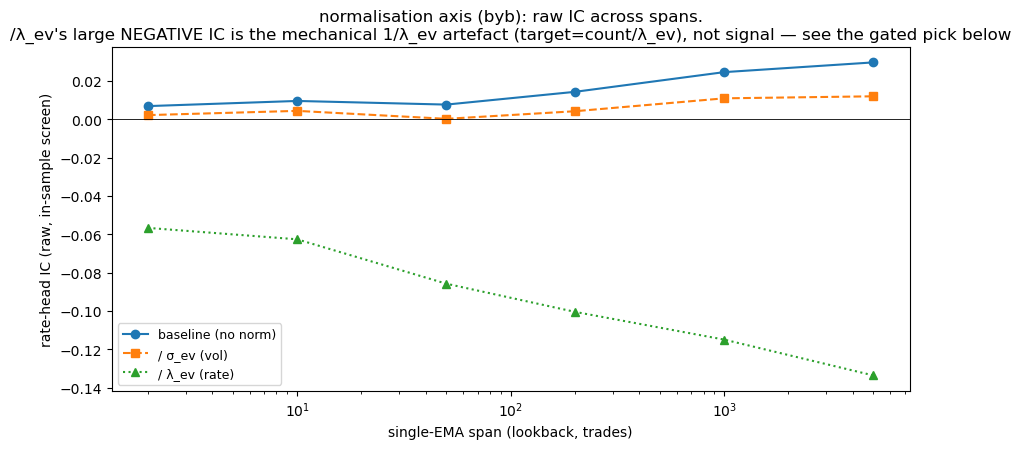

rate-head RAW IC by normalisation × span (byb, in-sample screen — NOT the decider):


  baseline  N=2:+0.007  N=10:+0.009  N=50:+0.008  N=200:+0.014  N=1000:+0.025  N=5000:+0.030


  sigma     N=2:+0.002  N=10:+0.004  N=50:+0.000  N=200:+0.004  N=1000:+0.011  N=5000:+0.012


  lambda    N=2:-0.057  N=10:-0.063  N=50:-0.086  N=200:-0.100  N=1000:-0.115  N=5000:-0.134


In [5]:
# rate-head target = byb moves (on the trade clock) in the next 100 ms, divided by λ_ev (the rate yardstick — the same trade-tick EMA).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])            # byb mid-moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual" (λ_ev is moves/sec over 100 ms, so this carries units of seconds; the constant horizon factor drops out of the rank correlation)

# --- the NORMALISATION axis across spans, for byb. We show raw IC (a screen) AND the honest standalone-within-σ_ev later. ---
def ic_rate(ex, span, norm): return spearmanr(volume_normalised(ex, span, norm), rate_target).statistic
norm_curves = {nm: [ic_rate("byb", N, nm) for N in SPANS] for nm in NORMS}
fig, ax = plt.subplots(figsize=(9, 4.6))
for nm, mk in zip(NORMS, ["o-", "s--", "^:"]):
    ax.plot(SPANS, norm_curves[nm], mk, label={"baseline":"baseline (no norm)","sigma":"/ σ_ev (vol)","lambda":"/ λ_ev (rate)"}[nm])
ax.set_xscale("log"); ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("single-EMA span (lookback, trades)"); ax.set_ylabel("rate-head IC (raw, in-sample screen)")
ax.set_title("normalisation axis (byb): raw IC across spans.\n/λ_ev's large NEGATIVE IC is the mechanical 1/λ_ev artefact (target=count/λ_ev), not signal — see the gated pick below")
ax.legend(fontsize=9); fig.tight_layout(); plt.show()
print("rate-head RAW IC by normalisation × span (byb, in-sample screen — NOT the decider):")
for nm in NORMS:
    print(f"  {nm:9}", "  ".join(f"N={N}:{ic_rate('byb',N,nm):+.3f}" for N in SPANS))

normalisation axis — HARD scale gate FIRST, standalone IC only among the survivors:
  baseline  scale 3.65x  [FAIL (drifts with regime — DISQUALIFIED)  ]  standalone rate IC +0.016  (best-signed span byb N=5000)
  sigma     scale 2.51x  [PASS                                      ]  standalone rate IC +0.018  (best-signed span byb N=5000)
  lambda    scale 2.07x  [PASS                                      ]  standalone rate IC +0.009  (best-signed span byb N=2)
->  BEST_NORM = sigma  (invariant: scale 2.51x < 3.0x; standalone IC +0.018 among survivors ['sigma', 'lambda'])
    NOTE: the un-normalised BASELINE scores standalone +0.016 but its scale is 3.65x —
    if that FAILS the hard invariance gate it is NOT a feature however it 'wins'; the shipped form is the best invariant one.


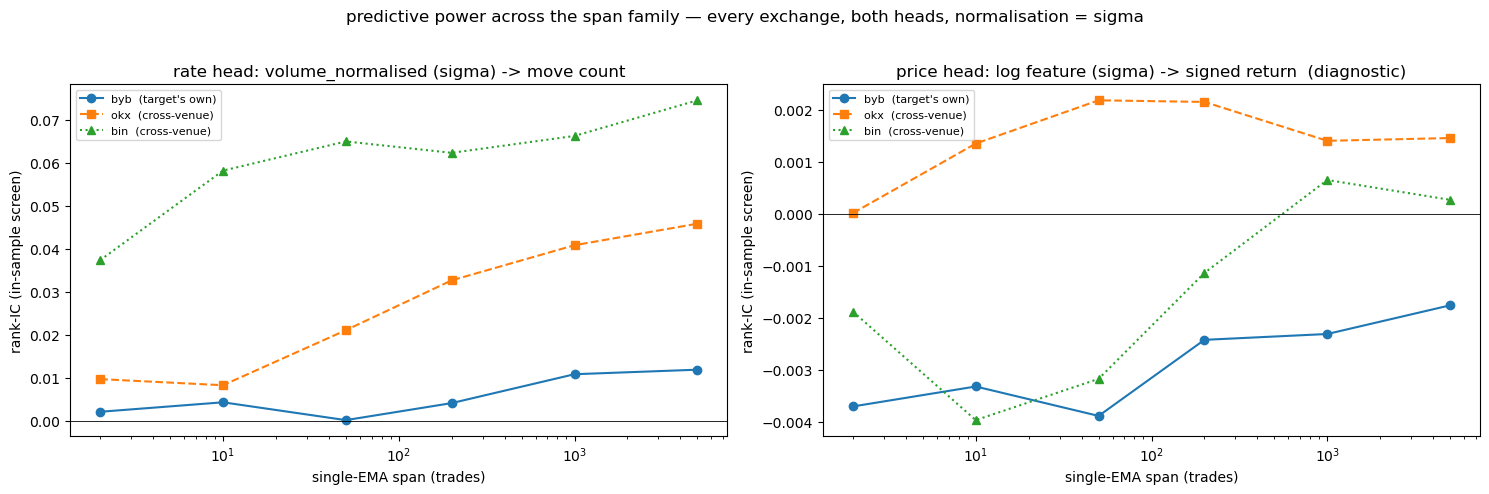

kept features (one per exchange, all fed to the model — none privileged):
  byb:  price head (span=50) IC=-0.004   |  rate head (span=5000) IC=+0.012
  okx:  price head (span=50) IC=+0.002   |  rate head (span=5000) IC=+0.046
  bin:  price head (span=10) IC=-0.004   |  rate head (span=5000) IC=+0.075


In [6]:
# Choose BEST_NORM in TWO stages — the regime-invariance scale gate is a HARD CONSTRAINT, applied FIRST:
#   (1) GATE: a usable feature must read the same in calm & wild markets. We measure each normalisation's SCALE —
#       the byb leg's std across vol-deciles, max/min — at that norm's best-signed span. A normalisation whose level
#       drifts with the regime (scale >~ 3x) is NOT a feature and is DISQUALIFIED, no matter its standalone IC.
#   (2) PICK: among the normalisations that PASS the hard scale gate, choose the largest honest STANDALONE rate-head IC
#       — the within-σ_ev-stratified standalone IC (signal_ic own=True), which decouples the shared σ_ev. A 0.001 IC
#       must NEVER select a non-invariant form: invariance gates first, IC only breaks ties among the invariant.
SCALE_GATE = 3.0                                      # HARD: max/min std across vol-deciles must stay under ~3x
def best_signed_span(ex, nm):                         # span whose SIGNED rate-head IC is largest (most positive)
    ics = [ic_rate(ex, N, nm) for N in SPANS]; return int(np.nanargmax(ics))
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))  # 10 vol buckets
def leg_scale(feat):                                  # the regime-invariance scale of one leg: max/min of its std across vol-deciles
    band = [np.nanstd(feat[vol_decile == d]) for d in range(10)]
    return max(band) / min(band)
norm_standalone, norm_scale, norm_span = {}, {}, {}
for nm in NORMS:
    spans_nm = {ex: SPANS[best_signed_span(ex, nm)] for ex in EXCHANGES}
    legs = {ex: volume_normalised(ex, spans_nm[ex], nm) for ex in EXCHANGES}
    norm_span[nm] = spans_nm
    # honest standalone rate-head IC for a CONTROL: signal_ic(own=True) -> within-λ_ev stratified (STRAT_VAR scored vs rate_target)
    norm_standalone[nm] = _gates.signal_ic(list(legs.values()), base, rate_target, feature_kind="control", own=True, strat_var=lam_at_anchor)
    norm_scale[nm]      = round(leg_scale(legs["byb"]), 2)              # byb leg's scale at this norm's chosen span (same construction every venue)
eligible = [nm for nm in NORMS if norm_scale[nm] < SCALE_GATE]          # ONLY the regime-invariant normalisations survive the hard gate
print("normalisation axis — HARD scale gate FIRST, standalone IC only among the survivors:")
for nm in NORMS:
    flag = "PASS" if norm_scale[nm] < SCALE_GATE else "FAIL (drifts with regime — DISQUALIFIED)"
    print(f"  {nm:9} scale {norm_scale[nm]:.2f}x  [{flag:42}]  standalone rate IC {norm_standalone[nm]:+.3f}  (best-signed span byb N={norm_span[nm]['byb']})")
assert eligible, "no normalisation passes the hard scale gate — feature is not regime-invariant in any form"
BEST_NORM = max(eligible, key=lambda nm: norm_standalone[nm])           # among the INVARIANT forms, the largest honest standalone IC
print(f"->  BEST_NORM = {BEST_NORM}  (invariant: scale {norm_scale[BEST_NORM]:.2f}x < {SCALE_GATE}x; standalone IC {norm_standalone[BEST_NORM]:+.3f} among survivors {eligible})")
print(f"    NOTE: the un-normalised BASELINE scores standalone {norm_standalone['baseline']:+.3f} but its scale is {norm_scale['baseline']:.2f}x —")
print(f"    if that FAILS the hard invariance gate it is NOT a feature however it 'wins'; the shipped form is the best invariant one.")

# Sweep the SPAN family for EVERY exchange, BOTH heads, at the chosen normalisation. No assumed leader.
price_grid = {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES}   # signed (log) feature -> byb's signed return
rate_grid  = {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES}   # feature level         -> byb's move count
feat_cache = {}
for ex in EXCHANGES:
    for i, N in enumerate(SPANS):
        d = volume_normalised(ex, N, BEST_NORM); feat_cache[(ex, N)] = d
        ld = np.log(np.maximum(d, 1e-300))                              # log = natural signed/centred form of a positive level
        price_grid[ex][i] = spearmanr(ld, target).statistic            # price head (diagnostic)
        rate_grid[ex][i]  = spearmanr(d, rate_target).statistic        # rate head: volume level -> move count (the feature's home)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for ax, grids, head in [(axes[0], rate_grid, f"rate head: volume_normalised ({BEST_NORM}) -> move count"),
                        (axes[1], price_grid, f"price head: log feature ({BEST_NORM}) -> signed return  (diagnostic)")]:
    for ex, mk in zip(EXCHANGES, ["o-", "s--", "^:"]):
        ax.plot(SPANS, grids[ex], mk, label=ex + ("  (target's own)" if ex=="byb" else "  (cross-venue)"))
    ax.set_xscale("log"); ax.axhline(0, color="k", lw=0.6)
    ax.set_xlabel("single-EMA span (trades)"); ax.set_ylabel("rank-IC (in-sample screen)"); ax.set_title(head); ax.legend(fontsize=8)
fig.suptitle(f"predictive power across the span family — every exchange, both heads, normalisation = {BEST_NORM}", y=1.02)
fig.tight_layout(); plt.show()

# Keep ALL exchanges. Pick the best span PER exchange, per head (in-sample pick; re-scored OOS by the gates).
# Rate head: SIGNED IC (positive-intensity hypothesis — heavier volume -> more moves). Price head: |IC| (direction can be either sign).
rate_member  = {ex: int(np.nanargmax(rate_grid[ex]))         for ex in EXCHANGES}
price_member = {ex: int(np.nanargmax(np.abs(price_grid[ex]))) for ex in EXCHANGES}
print("kept features (one per exchange, all fed to the model — none privileged):")
for ex in EXCHANGES:
    pi, ri = price_member[ex], rate_member[ex]
    print(f"  {ex}:  price head (span={SPANS[pi]}) IC={price_grid[ex][pi]:+.3f}   |  rate head (span={SPANS[ri]}) IC={rate_grid[ex][ri]:+.3f}")

does a 2nd span add over the pick? — price head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  byb: best alt N=2 (chosen N=50) partial-IC|best -0.002;  OOS joint +0.000 vs solo +0.001 (Δ-0.000)  ->  one span suffices (no OOS gain)


  okx: best alt N=2 (chosen N=50) partial-IC|best -0.001;  OOS joint +0.002 vs solo +0.002 (Δ+0.000)  ->  one span suffices (no OOS gain)


  bin: best alt N=1000 (chosen N=10) partial-IC|best +0.002;  OOS joint +0.002 vs solo +0.004 (Δ-0.002)  ->  one span suffices (no OOS gain)
does a 2nd span add over the pick? — rate head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  byb: best alt N=1000 (chosen N=5000) partial-IC|best +0.003;  OOS joint +0.024 vs solo +0.027 (Δ-0.003)  ->  one span suffices (no OOS gain)


  okx: best alt N=200 (chosen N=5000) partial-IC|best +0.013;  OOS joint +0.039 vs solo +0.051 (Δ-0.013)  ->  one span suffices (no OOS gain)


  bin: best alt N=10 (chosen N=5000) partial-IC|best +0.046;  OOS joint +0.081 vs solo +0.073 (Δ+0.008)  ->  one span suffices (no OOS gain)


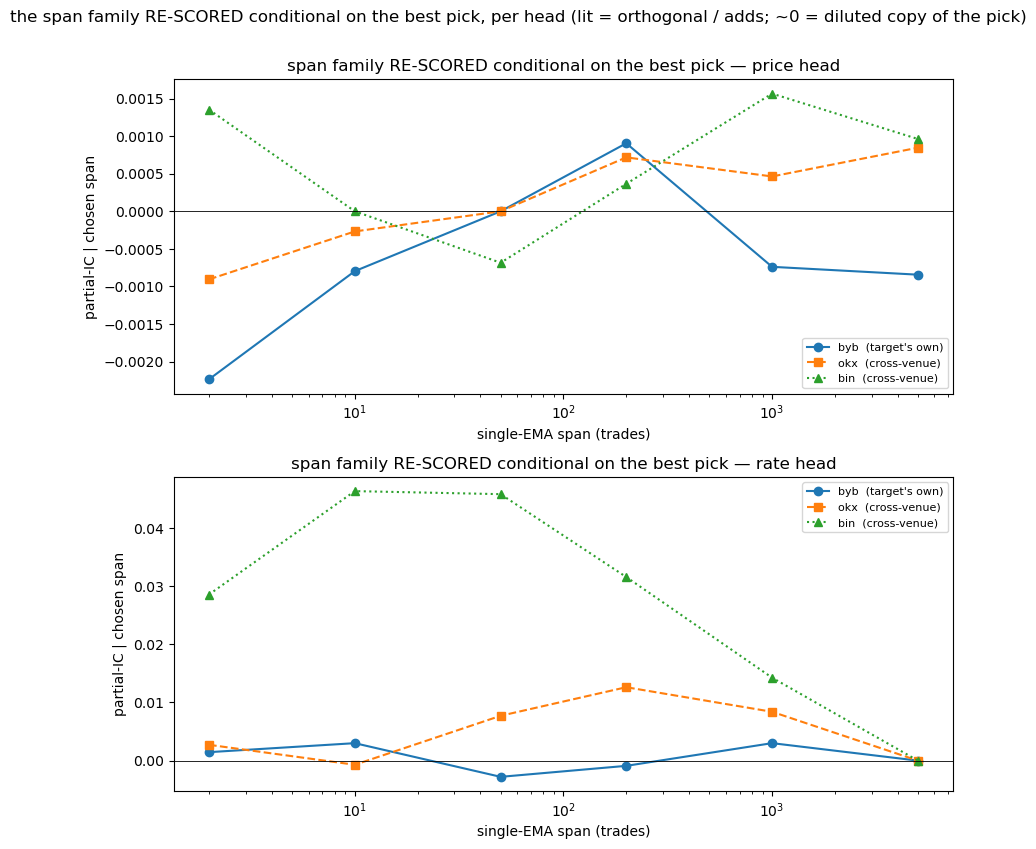

In [7]:
# === Does a SECOND time-scale ADD over the pick? — the span family RE-SCORED conditional on the best member, PER HEAD ===
# Selection lives here in §6. We picked the best span per head by IC; now re-score the WHOLE SPAN family as
# partial-IC(span | chosen) -- each span's IC against the head's target, CONTROLLING for the span we picked (the
# same partial-IC tool the echo-netting cell uses; control = the chosen span, not the trailing move).
# A span still LIT adds signal ORTHOGONAL to the pick; a span that COLLAPSES to ~0 is a diluted copy. This family is a
# single-span (1-D) sweep, so the reconditioned sweep is a per-head LINE (not a heat-map). The line is in-sample, so
# the keep/drop DECISION is the walk-forward joint-vs-solo OOS IC (wf_ic, imported in §5).
def _pic(f, y, c):                                                   # partial rank-IC of f with y, controlling for c
    m = np.isfinite(f) & np.isfinite(y) & np.isfinite(c)
    if m.sum() <= 100: return np.nan
    rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic
    return (rfy - rfc * rcy) / np.sqrt(max((1.0 - rfc**2) * (1.0 - rcy**2), 1e-12))

# Per head: feat() maps a span N to its scored feature, tgt is the head's target, member is the in-sample pick.
# Price head: SIGNED log(feature) vs the σ-return target. Rate head: |feature| vs the count target.
HEADS = [("price head", lambda ex, N: np.log(np.maximum(volume_normalised(ex, N, BEST_NORM), 1e-300)), target,      price_member),
         ("rate head",  lambda ex, N: np.abs(volume_normalised(ex, N, BEST_NORM)),                      rate_target, rate_member)]
fig, axes = plt.subplots(len(HEADS), 1, figsize=(9, 4.2 * len(HEADS)), squeeze=False)
second = {}
for row, (head, feat, tgt, member) in enumerate(HEADS):
    print(f"does a 2nd span add over the pick? — {head}: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:")
    ax = axes[row][0]
    for ex, mk in zip(EXCHANGES, ["o-", "s--", "^:"]):
        ci = member[ex]; chosen = feat(ex, SPANS[ci])
        cond = np.array([0.0 if i == ci else _pic(feat(ex, N), tgt, chosen) for i, N in enumerate(SPANS)])
        ax.plot(SPANS, cond, mk, label=ex + ("  (target's own)" if ex == "byb" else "  (cross-venue)"))
        bi = int(np.nanargmax(np.abs(cond)))                                   # the most-orthogonal alternative span (in-sample screen)
        f1, f2 = chosen, feat(ex, SPANS[bi])
        solo, joint = wf_ic([f1], tgt), wf_ic([f1, f2], tgt)                   # OOS: chosen alone vs the pair
        keep = bool((joint - solo) >= 0.01)                                    # the OOS joint gain DECIDES
        second[(head, ex)] = bi if keep else None
        print(f"  {ex}: best alt N={SPANS[bi]} (chosen N={SPANS[ci]}) partial-IC|best {cond[bi]:+.3f};  OOS joint {joint:+.3f} vs solo {solo:+.3f} (Δ{joint - solo:+.3f})"
              f"  ->  {'KEEP 2nd span (adds OOS)' if keep else 'one span suffices (no OOS gain)'}")
    ax.set_xscale("log"); ax.axhline(0, color="k", lw=0.6)
    ax.set_xlabel("single-EMA span (trades)"); ax.set_ylabel("partial-IC | chosen span"); ax.set_title(f"span family RE-SCORED conditional on the best pick — {head}"); ax.legend(fontsize=8)
fig.suptitle("the span family RE-SCORED conditional on the best pick, per head (lit = orthogonal / adds; ~0 = diluted copy of the pick)", y=1.005)
fig.tight_layout(); plt.show()

**Does a *second* time-scale add — per head?** The span sweep picks the best span per head; a second span is only
worth feeding if it carries signal the first doesn't. We test that by **re-scoring the whole span family conditional
on the chosen pick** — each span's IC recomputed as `partial-IC(span | chosen)`: its predictive power against the
head's target **controlling for the span we already picked** (the same partial-IC tool the echo-netting cell uses;
control = the chosen span). A span that stays **lit** is **orthogonal** — it adds new signal — while a span that
**collapses to ≈ 0** is a diluted copy of the pick. Because that line is **in-sample**, the keep/drop **decision** is
the overfitting-resistant **walk-forward joint-vs-solo** IC (`wf_ic([chosen, alt]) − wf_ic([chosen])`): keep the
second span only when the out-of-sample gain clears the ~0.01 floor. We run it for **both heads** (price → signed
`log(feature)` vs the σ-return target; rate → |feature| vs the count target). On this block both find the second
span a diluted copy (OOS gain ≈ 0), so one span per head suffices.

**Now the gates** — and they are **two independent tests**, not one. Because `volume_normalised` is a
**`control`** (a regime descriptor), Gate B is its **standalone** signal — marginal-over-its-own-controls
is circular — so the OWN-venue legs take the standalone branch (`own=True`), in-sample decoupled within the
shared yardstick (its out-of-sample confirmation comes from the multi-block harness in `tools/oss`). The
okx/bin **cross-venue** legs stay a genuine lead test (no own-feature circularity).

One caveat for **both heads**: the span is chosen by the in-sample heat-map *above* over the **whole** block,
so the IC below is **post-selection and provisional** — mildly optimistic, since the same data informed the
span pick. Held-out span selection is deferred to the multi-block `tools/oss` harness; here the choice is
among a small 6-span family of near-identical neighbours, so the selection bias is expected to be small (we
don't measure it on this single block).

**Gate A — regime invariance** (the feature *alone*): is the feature's distribution **stable against our regime
diagnostics**, or does it *leak* it? **Control-free** checks: **scale** — its std across vol buckets (max/min,
want **< ~3**); and then, for **both the signed feature *and* its magnitude `|feature|`**, two leak modes
against **both regime coordinates** (vol *and* rate level): **tracking** — `|IC(·, level)|` ≈ 0 (the monotone
test, want **< ~0.05** for the signed feature, **< ~0.1** for the magnitude), and **dispersion** — the spread
of its per-decile *means* (want **< ~0.1**), which catches a *non-monotone* leak the monotone IC misses. The
vol/rate level is only the regime *coordinate* here, **never** a control. *(A raw volume EMA usually fails
scale — its level **is** partly the regime — which is exactly why the §6 normalisation pick gates scale
**first**: the shipped `/σ_ev` form clears the **scale** bar. But scale is only one of four Gate A bars —
track / magnitude / dispersion are **separate hard gates** that §6 does **not** test, so they are measured
here, per head, and may still fail even when scale passes — as the rate head does below.)*

**Gate B — standalone signal (the control branch)**: a regime descriptor cannot be judged
marginal-over-its-own-controls (circular), so we score its **standalone** rank-IC, in-sample decoupled. Run
**per exchange** since the okx/bin legs are a real cross-venue lead test. **Mechanical-coupling guard:** the
§6 price-head gate scores the **σ_ev price target** by default, and the shipped form divides by σ_ev — so the
standalone IC is stratified **within σ_ev strata** (`STRAT_VAR = sigma_at_anchor`), multiplicatively
decoupling the shared denominator (the spurious correlation of ratios) where a linear partial would
over-remove genuine signal. *(The control-standalone stratified IC is **in-sample** decoupled; its
out-of-sample confirmation comes from `tools/oss`.)* *Regime-stable* (companion): is the standalone signal
still positive **within** calm, mid, and wild vol — not a one-regime artefact? **NB the price head is the
diagnostic for this intensity feature; its home (the rate head, against the count target) is gated next.**

In [8]:
# Gates on the per-exchange features — symmetric; KEEP ALL exchanges. volume_normalised is a CONTROL (a regime
# descriptor), so Gate B is its STANDALONE signal (marginal-over-its-own-controls is circular). own=True selects
# the standalone branch; STRAT_VAR=sigma_at_anchor stratifies within σ_ev (the σ_ev price target's denominator,
# which the shipped /σ_ev form shares). signal_ic / signal_ic_by_regime / stratified_ic / ic all come from
# boba.research.gates (the §5 wrappers bind base / FEATURE_KIND=control / STRAT_VAR / vol_regime).
# This cell scores the PRICE-SPAN feature against the σ_ev PRICE target (the diagnostic head); its HOME, the rate
# head against the count target, is gated in the next cell. We use the SIGNED log(feature) for the price head.
vn       = {ex: feat_cache[(ex, SPANS[price_member[ex]])] for ex in EXCHANGES}     # the chosen price-head feature per exchange (positive level)
vn_log   = {ex: np.log(np.maximum(vn[ex], 1e-300)) for ex in EXCHANGES}            # signed/centred form for the price head
joint = signal_ic(list(vn_log.values()), own=True)                                # standalone (control branch), within σ_ev strata
strat = signal_ic_by_regime(list(vn_log.values()), own=True)
print(f"joint Gate B standalone (price head, within σ_ev strata) {joint:.3f}")
rep = vn_log[EXCHANGES[0]]                              # representative leg — for the momenta-overlap sanity print only (Gate A runs PER EXCHANGE below)
# GATE A — regime invariance (vol_level/rate_level are the regime COORDINATE, never controls), run PER EXCHANGE
# (Gate A is a property of the output DISTRIBUTION, which differs by venue). gate_a(feat) comes from
# boba.research.gates via the §5 wrapper — scale / track / mag / disp vs the vol & rate regime coordinates
# (worst-coordinate per check); it computes its own equal-mass deciles internally.
# Sanity: a CONTROL is EXPECTED to overlap the momenta (it IS a regime descriptor) — large overlap is fine here.
print(f"FEATURE_KIND={FEATURE_KIND!r} | feature vs momenta |IC|: rate {abs(ic(rep, rate_momentum)):.3f} vol {abs(ic(rep, vol_momentum)):.3f}  (overlap EXPECTED for a control)")
gate_rows = [dict(gate="B · signal (price, standalone)", detail="all exchanges together — standalone within σ_ev strata", value=joint)]
gate_rows += [dict(gate="B · signal (price, standalone)", detail=f"{ex} alone — standalone within σ_ev strata"
                  + ("  [target's own volume]" if ex=="byb" else "  [cross-venue lead test]"),
                   value=signal_ic([vn_log[ex]], own=True)) for ex in EXCHANGES]
# σ_ev-coupling check: the signed log(feature) and the σ_ev price target. The standalone IC WITHIN σ_ev strata vs the
# UNSTRATIFIED raw IC — if the stratified is much smaller, the raw IC was an arithmetic σ_ev artefact.
gate_rows += [dict(gate="B · coupling (price)", detail=f"{ex} — log(feature) raw standalone IC, unstratified", value=round(ic(vn_log[ex], target), 3)) for ex in EXCHANGES]
gate_rows += [dict(gate="B · coupling (price)", detail=f"{ex} — log(feature) standalone IC WITHIN σ_ev strata (decoupled)", value=round(stratified_ic(vn_log[ex], target, sigma_at_anchor), 3)) for ex in EXCHANGES]
for ex in EXCHANGES:                                    # GATE A PER EXCHANGE (worst coordinate per check) — every venue, since the output distribution differs by venue
    a = gate_a(vn[ex])
    gate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — magnitude track, worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
gate_rows += [dict(gate="regime-stable (price)", detail=f"standalone within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(30); pl.Config.set_fmt_str_lengths(60)
pl.DataFrame(gate_rows)

joint Gate B standalone (price head, within σ_ev strata) -0.002


FEATURE_KIND='control' | feature vs momenta |IC|: rate 0.020 vol 0.139  (overlap EXPECTED for a control)


gate,detail,value
str,str,f64
"""B · signal (price, standalone)""","""all exchanges together — standalone within σ_ev strata""",-0.002
"""B · signal (price, standalone)""","""byb alone — standalone within σ_ev strata [target's own vol…",-0.004
"""B · signal (price, standalone)""","""okx alone — standalone within σ_ev strata [cross-venue lead…",0.002
"""B · signal (price, standalone)""","""bin alone — standalone within σ_ev strata [cross-venue lead…",-0.004
"""B · coupling (price)""","""byb — log(feature) raw standalone IC, unstratified""",-0.004
"""B · coupling (price)""","""okx — log(feature) raw standalone IC, unstratified""",0.002
"""B · coupling (price)""","""bin — log(feature) raw standalone IC, unstratified""",-0.004
"""B · coupling (price)""","""byb — log(feature) standalone IC WITHIN σ_ev strata (decoupl…",-0.004
"""B · coupling (price)""","""okx — log(feature) standalone IC WITHIN σ_ev strata (decoupl…",0.002


**Conclusion (price head — the diagnostic).** The price head is the *diagnostic* for this intensity
feature — we expect little *directional* signal, and the standalone log-volume IC against the σ_ev price
target is ≈ 0 (joint −0.002; byb −0.004, okx +0.002, bin −0.004 — volume is intensity, not which way), and
it survives the within-σ_ev stratify (so the small number is not even a σ_ev artefact). **Gate A** is the
load-bearing check here, run per exchange (a distribution property — venues differ): the shorter price-head
span (`span=50/10`) **only borderline clears** invariance — scale passes comfortably (byb 1.85, okx 1.3, bin
1.2, all < ~3), but the track/dispersion rows sit **right on or just over** their bars on two venues (byb
signed-track 0.057 / dispersion 0.107; bin 0.088 / 0.115, against 0.05 / 0.1; okx passes at 0.041 / 0.069).
So the diagnostic head is **marginal-to-borderline** on Gate A, not a clean pass — and the §6 scale-first pick
gates **scale only**, never track/mag/dispersion, so passing §6 does **not** by itself certify Gate A. The
**rate head — this feature's home — is gated separately just below** against the count target, where (as we
will see) it **FAILS** Gate A's track/mag/dispersion outright; that verdict is NOT inherited from this
diagnostic price head, and is the one that decides shipping.

**Now the rate head — its own gates, against the count target.** The block above gated the *price-span*
feature against the σ_ev **price** target. The rate head is fed a **different-span** feature (the sharp
`rate_member` pick) and predicts the **count** target, so its verdict is **not** inherited from the price
gates — it gets the same two-gate battery here.

The rate head's signal lives in the **magnitude**: `|feature| → count` is the §6 diagnostic, and the model
is fed the **signed** feature and recovers `|·|` itself (a nonlinear head can). So **Gate B scores
`|feature|`** — a *linear* score on the signed feature would read ≈ 0 precisely because the count
relationship is symmetric, so `|feature|` is the honest proxy for what the nonlinear rate head extracts.
**Coupling guard:** the price head could use `STRAT_VAR=None` because its **signed** numerator decouples the
shared σ_ev; the magnitude path has no sign to decouple it, and `|feature| ∝ 1/σ_ev` while `count/λ_ev ∝
1/λ_ev` share the byb-activity regime — so we add a **within-λ_ev stratified** line per exchange to confirm
the marginal isn't a `1/λ_ev` artefact. **Gate A** is re-run **per exchange** on the rate-span feature (a
distribution property — it differs by venue *and* by span).

In [9]:
# === RATE-HEAD GATES ===
# The price-head gates above ran the price-SPAN feature against the σ_ev price target. The rate head is fed a
# DIFFERENT-span feature (the rate_member pick) and predicts the COUNT target, so its verdict can't be inherited
# from the price gates — it gets the SAME two-gate battery here, against the count target.
#  * The rate head's signal lives in the MAGNITUDE: |feature|->count is the §6 diagnostic, and the model is fed the
#    SIGNED feature and recovers |.| internally (a nonlinear head can). So Gate B scores |feature| — a LINEAR score
#    on the signed feature reads ~0 precisely because the count relationship is symmetric; |feature| is the honest
#    proxy for what the nonlinear rate head extracts.
#  * Coupling guard: the price head could set STRAT_VAR=None because its SIGNED numerator decouples the shared σ_ev.
#    The magnitude path has no sign to decouple it, and |feature| ~ 1/σ_ev while count/λ_ev ~ 1/λ_ev share the byb-
#    activity regime — so we add a within-λ_ev stratified line per exchange to confirm the marginal is not a 1/λ_ev artefact.
#  * Gate A is re-run PER EXCHANGE on the rate-span feature (a distribution property — it differs by venue AND by span).
# volume_normalised is a CONTROL, so the rate-head Gate B is its STANDALONE signal (own=True), within λ_ev strata
# (the count target's denominator the shipped /λ_ev form shares) — marginal-over-its-own-controls would be circular.
vn_rate     = {ex: feat_cache[(ex, SPANS[rate_member[ex]])] for ex in EXCHANGES}        # the chosen rate-head feature per exchange (positive level)
mag_rate    = {ex: np.abs(vn_rate[ex]) for ex in EXCHANGES}                              # the rate head sees |feature| (symmetric count relationship)

joint_rate  = _gates.signal_ic(list(mag_rate.values()), base, rate_target, feature_kind="control", own=True, strat_var=lam_at_anchor)   # standalone |feature|->count, within λ_ev strata, all venues together
strat_rate  = _gates.signal_ic_by_regime(list(mag_rate.values()), base, rate_target, vol_regime, feature_kind="control", own=True, strat_var=lam_at_anchor)  # the calm/mid/wild companion
print(f"joint Gate B (rate) standalone {joint_rate:.3f}")
# gate_a (worst-coordinate Gate A, used for both heads) is defined in the §6 price-gate cell above.

rate_rows  = [dict(gate="B · signal (rate, standalone)", detail="all exchanges together — standalone |feature|->count within λ_ev strata; want >~ 0.01", value=joint_rate)]
rate_rows += [dict(gate="B · signal (rate, standalone)", detail=f"{ex} alone — standalone |feature|->count within λ_ev strata"
                  + ("  [target's own volume]" if ex=="byb" else "  [cross-venue lead test]"),
                   value=_gates.signal_ic([mag_rate[ex]], base, rate_target, feature_kind="control", own=True, strat_var=lam_at_anchor)) for ex in EXCHANGES]
rate_rows += [dict(gate="B · coupling (rate)", detail=f"{ex} — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artefact)",
                   value=round(stratified_ic(mag_rate[ex], rate_target, lam_at_anchor), 3)) for ex in EXCHANGES]
for ex in EXCHANGES:
    a = gate_a(vn_rate[ex])
    rate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — the rate head sees |feature|, worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
rate_rows += [dict(gate="regime-stable (rate)", detail=f"|feature|->count within {nm}-vol (companion: stay positive)", value=strat_rate.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(25); pl.Config.set_fmt_str_lengths(70)
pl.DataFrame(rate_rows)

joint Gate B (rate) standalone 0.018


gate,detail,value
str,str,f64
"""B · signal (rate, standalone)""","""all exchanges together — standalone |feature|->count within λ_ev strat…",0.018
"""B · signal (rate, standalone)""","""byb alone — standalone |feature|->count within λ_ev strata [target's …",0.011
"""B · signal (rate, standalone)""","""okx alone — standalone |feature|->count within λ_ev strata [cross-ven…",0.021
"""B · signal (rate, standalone)""","""bin alone — standalone |feature|->count within λ_ev strata [cross-ven…",0.022
"""B · coupling (rate)""","""byb — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev a…",0.011
"""B · coupling (rate)""","""okx — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev a…",0.021
"""B · coupling (rate)""","""bin — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev a…",0.022
"""A · regime-inv (byb)""","""feature scale across vol buckets (max/min) — HARD, want < ~3""",2.51
"""A · regime-inv (byb)""","""|IC(feature, vol/rate level)| — signed mean-track, worst coord; want <…",0.402


**Conclusion (rate head — this feature's home), and it FAILS Gate A.** The rate-span feature (the long
`span=5000` `rate_member` pick) is put through the same battery against the **count** target, every exchange,
on its **standalone** branch (a `control` can't be judged marginal-over-its-own-controls). Read the verdict
straight off the printed table — and the verdict is **negative**:

- **Gate B** carries a *little* standalone signal: `|feature| → count` is +0.018 jointly (byb +0.011, okx
  +0.021, bin +0.022), survives the **within-λ_ev** stratify (the coupling rows match, so it is not a pure
  `1/λ_ev` arithmetic artefact), and stays positive across calm / mid / wild (+0.013 / +0.021 / +0.026). That
  much is what a weak intensity feature should do.
- **Gate A FAILS hard on every venue.** The two gates are **independent**, and Gate A's track / magnitude /
  dispersion are **hard** bars (the guard rails: "All are hard gates"; "Never call a feature regime-invariant …
  until *every* Gate A number says so"). Only **scale** passes (byb 2.51, okx 1.18, bin 1.99, all < ~3); the
  other three rows **blow through their bars by 1.5–8×** on every venue:

  | venue | scale (< ~3) | signed-track (< ~0.05) | magnitude-track (< ~0.1) | dispersion (< ~0.1) |
  |---|---|---|---|---|
  | byb | 2.51 PASS | **0.402 FAIL** | **0.402 FAIL** | **0.436 FAIL** |
  | okx | 1.18 PASS | **0.156 FAIL** | **0.156 FAIL** | **0.235 FAIL** |
  | bin | 1.99 PASS | **0.365 FAIL** | **0.365 FAIL** | **0.371 FAIL** |

So by the hard-gate rule the shipped sigma-normalised volume EMA at the rate-head span is **NOT
regime-invariant**: scale being stable does **not** rescue track/mag/disp, and the §6 pick gated **scale
only** — it never gated track/mag/dispersion, so passing §6 does **not** make this form pass Gate A. At
`span=5000` the `/σ_ev` leg still *tracks the regime level* (|IC| ~0.16–0.40 vs a 0.05 bar), so it is largely
re-reporting "the market is busy/volatile" rather than reading the same in calm and wild. **It must NOT ship
as-is in this rate-head form** — the Gate A failure is the load-bearing result here, not the small Gate B IC.
(Why it fails where the price head's shorter span nearly passes: dividing by `σ_ev` only fully cancels the
regime when the volume EMA's span and `σ_ev`'s span co-move tightly; at the long `span=5000` rate pick the
volume level drifts with the vol regime that `σ_ev` doesn't absorb, so the residual tracks. A shorter
rate-head span, or a different normaliser, is the open fix — to be measured, not assumed.) So the rate head
gets its **own** verdict here, against the count target, and it is a **Gate A failure**, not a pass inherited
from the diagnostic price head.

### Self-test — does the stratify-by-yardstick decouple actually work?

The alpha worked example above never exercises the **control** branch (`FEATURE_KIND="control"`, own-leg,
`STRAT_VAR` set), so this small cell checks the one thing that branch relies on: that **stratifying by the
shared yardstick kills a purely-mechanical ratio coupling while keeping a real signal**. We build, on the
grid, a `count/λ_ev`-style rate-head target and two control *ratios that both divide by `λ_ev`* (so
`STRAT_VAR = lam_at_anchor`):
- **pure-spurious** — a numerator with **no** real link to the count, divided by `λ_ev`. Its **raw** Spearman
  against the target is large (the shared `1/λ_ev` manufactures it); **stratified** by `λ_ev` it collapses to ≈0.
- **real-signal** — a numerator that genuinely tracks the count, divided by `λ_ev`. Its raw IC is inflated by
  the same coupling, but the **stratified** IC keeps the genuine within-stratum signal.

If `stratified_ic` returns ≈0 for the spurious ratio (vs a large raw IC) and recovers the real one, the
decouple does what Gate B's control branch needs.

In [10]:
# SELF-TEST of the control-branch decouple (does NOT touch the alpha worked example above).
rng = np.random.default_rng(0)
# a count/λ_ev-style rate-head target on the grid (the same shape rate_target has)
st_count  = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")]).astype(float)   # byb moves over the next 100 ms
st_target = st_count / np.maximum(lam_at_anchor, 1e-9)                               # count ÷ λ_ev (the scored ratio target)
st_lam    = lam_at_anchor                                                            # the shared yardstick == STRAT_VAR

# PURE-SPURIOUS control ratio: numerator independent of the count, divided by the SAME λ_ev -> shares only the denominator.
# Keep the numerator nearly CONSTANT so the shared 1/λ_ev dominates the ratio's variance -> a fake raw IC the stratify removes.
spur_num   = 1.0 + 0.25 * rng.standard_normal(len(anchor_ts))                        # constant-ish, count-independent numerator
spur_ratio = spur_num / np.maximum(st_lam, 1e-9)
# REAL-signal control ratio: numerator that genuinely predicts the count, divided by the SAME λ_ev.
real_num   = st_count + 3.0 * rng.standard_normal(len(anchor_ts))                    # tracks the count (with noise)
real_ratio = real_num / np.maximum(st_lam, 1e-9)

def _raw(f, y):
    m = np.isfinite(f) & np.isfinite(y); return float(spearmanr(f[m], y[m]).statistic)
print("control-branch decouple self-test — THROUGH signal_ic (target = count/λ_ev, STRAT_VAR = λ_ev, heavy-tailed):")
spur_raw, real_raw = _raw(spur_ratio, st_target), _raw(real_ratio, st_target)
_k, _s = FEATURE_KIND, STRAT_VAR                                          # BLOCKER-2: exercise the REAL gate path (signal_ic), not stratified_ic directly
try:
    globals().update(FEATURE_KIND="control", STRAT_VAR=st_lam)           # st_lam == lam_at_anchor is genuinely heavy-tailed (ISSUE-5 stress)
    spur_gate = signal_ic([spur_ratio], own=True, tgt=st_target)
    real_gate = signal_ic([real_ratio], own=True, tgt=st_target)
finally:
    globals().update(FEATURE_KIND=_k, STRAT_VAR=_s)
print(f"  pure-spurious:  raw Spearman {spur_raw:+.3f}  ->  signal_ic {spur_gate:+.3f}   (want raw large, gated ~0)")
print(f"  real-signal:    raw Spearman {real_raw:+.3f}  ->  signal_ic {real_gate:+.3f}   (want signal kept)")
assert abs(spur_gate) < 0.04,                      f"stratify failed to kill the spurious heavy-tailed coupling ({spur_gate:+.3f})"
assert abs(spur_raw) > 3 * abs(spur_gate) + 0.04,  f"spurious raw IC not materially larger than gated ({spur_raw:+.3f} vs {spur_gate:+.3f})"
assert abs(real_gate) > 0.05,                      f"stratify destroyed the real signal ({real_gate:+.3f})"
print("  OK — the gate's control path decouples the spurious heavy-tailed ratio and keeps the real signal.")

control-branch decouple self-test — THROUGH signal_ic (target = count/λ_ev, STRAT_VAR = λ_ev, heavy-tailed):


  pure-spurious:  raw Spearman -0.151  ->  signal_ic -0.005   (want raw large, gated ~0)
  real-signal:    raw Spearman +0.133  ->  signal_ic +0.166   (want signal kept)
  OK — the gate's control path decouples the spurious heavy-tailed ratio and keeps the real signal.


## Is the edge real prediction, or an echo of the move already underway?

A feature can be perfectly causal and still not *predict*: if its apparent edge is the price move **already
underway** at the anchor, you can't capture it — by the time you observe, decide, and act, that move is gone — and
a purely *contemporaneous* feature can post a positive forward IC from window overlap alone. So before trusting a
forward IC, **net out the echo**: measure the feature's correlation with the **forward** return
(`[anchor, anchor+100 ms]`) *controlling for the move that already happened* (`[anchor−100 ms, anchor]`). The
**backward IC** sizes the echo; the **echo-netted** forward IC is what survives once it's partialled out — the
genuinely forward-looking edge. (It's the same partial-IC tool §6 uses to test a second time-scale — here the
control is the trailing move instead of the chosen span.)

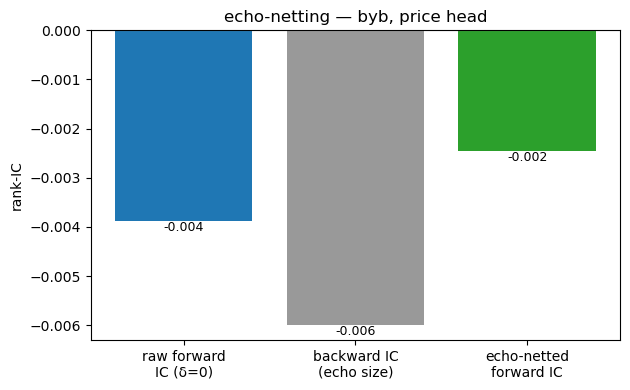

raw forward IC -0.004;  backward (echo) IC -0.006;  echo-netted forward IC -0.002  (the raw->netted shortfall is echo)


In [11]:
# Echo-netting: is the edge real prediction, or just re-reporting the move ALREADY underway at the anchor?
rep_ex = EXCHANGES[0]                                    # one exchange to illustrate; every feature carries its own
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    idx = np.searchsorted(byb_rx, t, "right") - 1; return np.where(idx < 0, np.nan, byb_mid[np.clip(idx, 0, len(byb_mid) - 1)])   # nan before byb's first quote
def _ret(t0, t1): return np.log(_mid_at(t1) / _mid_at(t0))
def _partial_ic(f, y, t):                                # partial rank-IC of f with y, CONTROLLING for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

signed = np.log(np.maximum(feat_cache[(rep_ex, SPANS[price_member[rep_ex]])], 1e-300))   # the chosen price-head feature (signed log(volume EMA))
_fwd0  = _ret(anchor_ts, anchor_ts + HORIZON_NS)          # forward 100 ms return — what we predict
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts)          # the move ALREADY underway at the anchor
raw_ic   = _ic(signed, _fwd0)                             # raw forward IC
back_ic  = _ic(signed, _trail)                            # backward IC — sizes the contemporaneous echo
echo_net = _partial_ic(signed, _fwd0, _trail)             # forward IC NETTED of the echo (controls for the trailing move)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
labels = ["raw forward\nIC (δ=0)", "backward IC\n(echo size)", "echo-netted\nforward IC"]
vals = [raw_ic, back_ic, echo_net]
bars = ax.bar(labels, vals, color=["C0", "0.6", "C2"])
ax.axhline(0, color="0.7", lw=0.8); ax.set_ylabel("rank-IC"); ax.set_title(f"echo-netting — {rep_ex}, price head")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
fig.tight_layout(); plt.show()
print(f"raw forward IC {raw_ic:+.3f};  backward (echo) IC {back_ic:+.3f};  echo-netted forward IC {echo_net:+.3f}  (the raw->netted shortfall is echo)")

**Net the echo out — don't report a forward IC a contemporaneous predictor could fake.** The cleanest
"is this real prediction?" number is the **echo-netted (partial) forward IC** above: the feature's rank-IC with
the *forward* return *controlling for the trailing* `[anchor−100 ms, anchor]` return. If a big raw IC collapses
once the trailing move is partialled out, the feature was mostly re-reporting the move already underway — report
the **netted** number in the verdict, not the raw IC. (A near-zero netted IC alongside a large backward IC is the
one true non-signal: all echo, no prediction.)

**Cross-venue legs: a freshness lead is *real edge*, not an artifact to coarsen away.** The data is recorded
on a production box in the target datacenter, so each event's `rx_time` is exactly the timing you'd see live —
there is **no recording/snapshot artifact** to rule out. So when okx's book moves before byb's reflects it
(byb/okx top-of-book is stale p90 ~100–160 ms vs bin's sub-ms), that lead is **genuine and exploitable**, and
the *mechanism* (economic price-discovery vs pure latency lead-lag) is irrelevant to P&L. Do **not** coarsen the
foreign feed to byb's cadence — that throws the edge away. *(A freshness lead would only be fake if the
recording's cadence didn't match production — e.g. a backtest on vendor snapshots; not the case here, where the
recording* is *production timing.)*

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by
the feature and look at the real distributions the two heads care about:
- **price head:** byb's next return for low / middle / high feature values — it should tilt
  one way as the feature turns positive and the other as it turns negative;
- **rate head:** how the number of upcoming moves grows as the feature's *magnitude* grows.

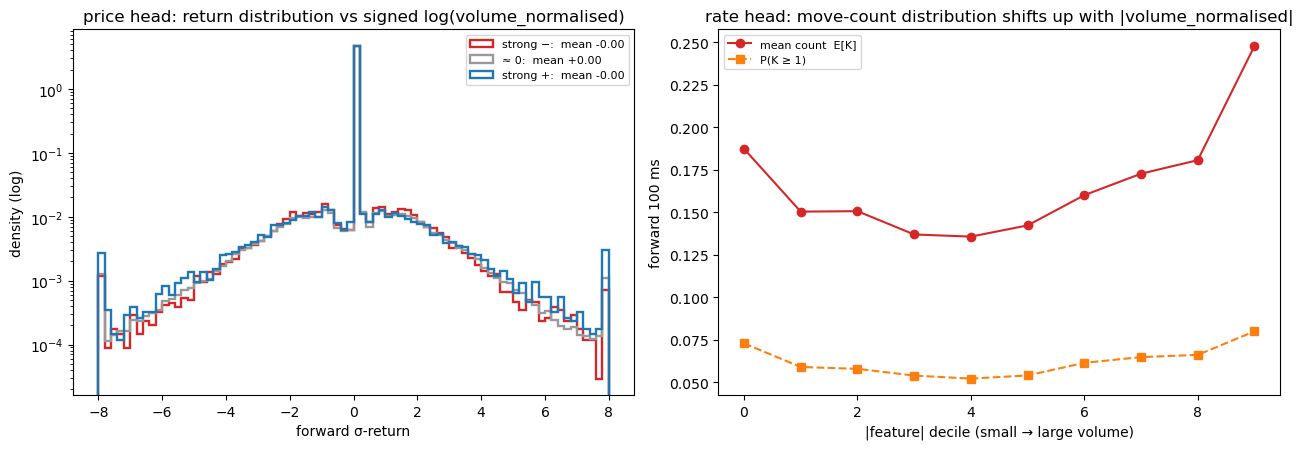

In [12]:
rep_ex = EXCHANGES[0]                                                           # one exchange shown to illustrate the shape; the model still uses every exchange
signed = np.log(np.maximum(feat_cache[(rep_ex, SPANS[price_member[rep_ex]])], 1e-300))                 # price head: signed log(volume EMA)
absmag = np.abs(feat_cache[(rep_ex, SPANS[rate_member[rep_ex]])])  # deliberately the RATE-head span (rate_member), not the price-head span — same feature, rate-head's own span pick
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across signed log(feature) buckets
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("strong −", signed <= lo, "C3"), ("≈ 0", (signed > lo) & (signed < hi), "0.6"),
          ("strong +", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axA.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title("price head: return distribution vs signed log(volume_normalised)"); axA.legend(fontsize=8)

# rate head: forward move-count shifts up with |feature|
# raw fwd_count is shown here only for intuition; the rate head's actual target is rate_target = fwd_count / λ_ev (count ÷ λ_ev)
dec = np.digitize(absmag, np.nanpercentile(absmag, np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel("|feature| decile (small → large volume)"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: move-count distribution shifts up with |volume_normalised|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The feature moves the *actual outcome distributions* the way §1 predicted —
not just a single summary number. **Price head (left):** the forward-return distribution barely
separates across the low / middle / high log-volume buckets (their means cluster near 0) — exactly
the *weak* directional signal expected of an intensity feature: volume says *how much*, not *which
way*. **Rate head (right) — its home:** both the mean move-count `E[K]` and `P(K ≥ 1)` climb from
the smallest to the largest `|feature|` decile — heavier recent trade size really does precede more
byb mid-moves. So the signal lives where §1 said it would (the rate head), and the price-head
diagnostic stays weak.

## 8. Input shaping for the network

This is a *different* step from §2. There we divided out volatility (the "regime division") so
the feature means the same thing in any market. Here we reshape the feature for the neural
network's input — roughly centred, unit-scale, no wild outliers.

Pick the **lightest** transform that does the job. Plot the feature (left) and compare a few
candidates by how close to a clean bell curve they make it (right — points on the diagonal are
perfectly normal). A symmetric, mild feature only needs a simple rescale (z-score: subtract
the mean, divide by the standard deviation); a heavily skewed or fat-tailed one needs more
(e.g. a rank-to-normal map: sort the values and reassign them onto a bell curve). The plot
makes the choice for you.

feature: std=1.1  skew=+0.41  excess_kurt=0.4  (0 = normal)
  z-score            excess_kurt=   0.4   max|·|=5.9
  robust + clip ±4   excess_kurt=   0.4   max|·|=4.0
  arcsinh(robust)    excess_kurt=  -0.8   max|·|=2.5
  rank-Gaussian      excess_kurt=  -0.0   max|·|=5.0


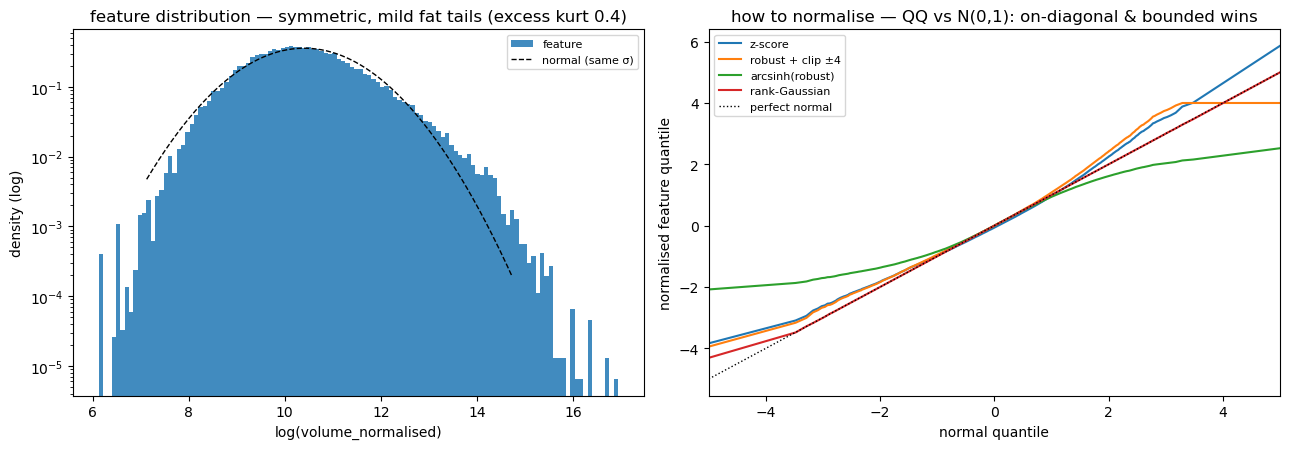

In [13]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_ex = EXCHANGES[0]                                                           # one exchange shown to illustrate the shape (same construction for every exchange)
f = np.log(np.maximum(feat_cache[(rep_ex, SPANS[price_member[rep_ex]])], 1e-300)); f = f[np.isfinite(f)]   # signed log(volume EMA), price-head span
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)); rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / f.std(),
        "robust + clip ±4": np.clip(rz, -4, 4),
        "arcsinh(robust)": np.arcsinh(rz),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature: std={f.std():.1f}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:18} excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="feature")
xg = np.linspace(np.percentile(f, 0.05), np.percentile(f, 99.95), 300)
axA.plot(xg, norm.pdf(xg, f.mean(), f.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel("log(volume_normalised)"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution — symmetric, mild fat tails (excess kurt {kurtosis(f):.1f})")
axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** Read the choice straight off the printout. Working in **log space** (the natural
form for a positive level like a volume EMA) already pulls the raw, heavy-right-skewed `E/W` mean qty
into a roughly symmetric, mild distribution, so a plain rescale (z-score) gets the bulk right. Whatever
residual outlier spike remains (the printed `max|·|` for the z-score) is tamed by the lightest transform
that *meets* the "no wild outliers" bar — a robust z-score followed by a clip (robust + clip ±4 →
`max|·|` = 4.0), the form you feed a network. The heavier transforms (arcsinh, rank-Gaussian) flatten
the tails further but would throw information away here. A more skewed or fat-tailed feature would push
you the other way; the QQ-plot tells you which.

**Still to run** (same machinery): whether the feature adds over features we already have;
whether the signal is steady day-to-day; and whether it survives out-of-sample across a
market-regime change. (The leak check *inside* volatility buckets is no longer pending —
Gate A's checks and the regime-stable companion now run it.)

## 9. When is per-exchange worth it? (for poolable features)

`volume_normalised` is a genuine *per-exchange* number (one normalised volume EMA per venue), and —
unlike a cross-venue *gap* — it **is poolable**: you can collapse the venues into one pooled volume
EMA. So you face a real choice: keep them **per-exchange**, collapse to **one exchange**, or **pool**
them all? The answer depends on the time-scale, so sweep it and compare the three (the §6 heat-maps
already give the real per-exchange numbers across the span family).

> **The table below is an illustrative example of the typical poolable-feature pattern**, predicting
> byb's next 100 ms — the real per-exchange numbers for `volume_normalised` are the §6 heat-maps. It
> just shows the shape the sweep usually takes. The time-scale column is labelled in ms / seconds only
> for readability — those wall-clock figures are just a translation of points on the trade-span N clock;
> the actual sweep is over trade-span N, as everywhere else.

| time-scale | pooled | best single | per-exchange | what it means |
|---|---|---|---|---|
| ≤ 50 ms | 0.22 | **0.23** | 0.22 | one exchange is enough — splitting just adds noise |
| ~500 ms | 0.11 | 0.12 | **0.16** | keep per-exchange — exchanges genuinely differ here |
| ≥ 2.5 s | 0.08 | 0.08 | 0.09 | exchanges agree — any one will do |

So: at the shortest scales the signal lives in one exchange; in a **middle band** the
exchanges genuinely differ (who's leading whom) and keeping them separate pays off; at long
scales they all converge. In this typical pattern pooling is rarely the best — it tends to blur
the middle-band structure; that's why you sweep and compare the three (per-exchange / single /
pooled) rather than pool by default. (Longer prediction horizons push the useful band wider, so in general
sweep the horizon too.)

## 10. The verdict, and what it takes to ship

**DON'T ship as-is — the feature's home (the rate head) FAILS Gate A on every venue.** The two gates are
independent and Gate A is a set of **hard** bars; the §6 rate-head gate table shows the shipped sigma-normalised
volume EMA at the rate-head span (`span=5000`) misses three of its four Gate A bars on **all three** venues
(signed-track / magnitude-track / dispersion: byb 0.402 / 0.402 / 0.436, okx 0.156 / 0.156 / 0.235, bin 0.365 /
0.365 / 0.371, against 0.05 / 0.1 / 0.1 bars; only **scale** passes). So at this span the feature still
**tracks the vol/rate regime level** — it is re-reporting "the market is busy/volatile" rather than reading the
same in calm and wild — and by the hard-gate rule it is **not regime-invariant** in this rate-head form. The
small Gate B standalone IC (~0.018) does **not** override that: invariance is the prerequisite, and it fails.
**Verdict: the rate-head form as shipped (`/σ_ev`, `span=5000`) must NOT ship.** The fix to *measure* (not
assume) before any ship: a **shorter rate-head span**, or a **different normaliser**, that actually clears
Gate A's track/mag/dispersion — re-run §6's rate-head battery on the candidate and confirm every bar passes.

- **Price head (direction) — the diagnostic head.** Expected *weak*, and it is (standalone log-volume IC ≈ 0;
  volume is intensity, not direction). Its Gate A at the shorter price-head span is **borderline** — byb
  signed-track 0.057 / dispersion 0.107 and bin track 0.088 / dispersion 0.115 sit just **over** their 0.05 /
  0.1 bars, while okx passes — so even the diagnostic head only marginally clears invariance, and carries
  essentially no directional signal regardless. Not a reason to ship on its own.
- **Rate head (intensity) — this feature's home — FAILS Gate A** (the table above). The *level/magnitude* of
  the long-span volume EMA does climb with the forward move-count (§7), and the standalone `|feature| → count`
  IC stays a positive ~0.011–0.022 across venues and across calm/mid/wild — but that signal sits on top of an
  un-removed regime track (track/mag ~0.16–0.40), so it cannot be shipped as a regime-invariant feature in
  this form. The Gate A failure is the load-bearing result, not the IC.

Feeding logic, **once a Gate-A-passing form is found**: feed **every exchange's** *signed* `log(feature)` (let
the nonlinear rate head recover `|·|` and learn how venues cancel/reinforce; don't collapse to a single
"leader," don't pre-`|·|`). The chosen normalisation rescales the volume EMA; the move-count it predicts is
divided by the rate yardstick. None of that applies until the rate-head form clears Gate A.

**To ship (currently BLOCKED on the first box):**
- [ ] **FAILING:** a rate-head form (span / normaliser) that passes **all** of Gate A's bars — the shipped
      `/σ_ev`, `span=5000` form fails track/mag/dispersion on every venue (see §6 rate-head table)
- [ ] the streaming (constant-work-per-trade) builder, matching this analysis version
- [ ] the tests, passing
- [ ] the gate results recorded (the rate-head Gate A failure recorded here; ship only once justified or fixed)
- [ ] the chosen heads and time-scales written down, with the yardstick spans
- [ ] the data quirks handled (bad zero-price prints; the right price source per exchange)